In [1]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model

model = "gpt-oss:20b"
#model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=0, 
    timeout=30,
    max_tokens=1000,
)

async def _invoke(messages):
    history_message = []
    history_message.append(SystemMessage(content=messages[0]))
    for msg in messages[1:]:
        history_message.append(msg)
        response = await llm.ainvoke(history_message)
        history_message.append(response)
    display(history_message)

In [39]:
#zero-shot prompting
"""
Zero-shot prompting provides only a task description without examples, relying on the model's training patterns.
Simply describe the task clearly, provide input data, and optionally specify output format. 
Works well for simple classification, text generation, translation, general Q&A, basic arithmetic...but may produce inconsistent results for complex tasks.
"""
system_prompt = """
 You are an useful assistant.
"""
user_messages = [
 "What is the capital of France?",
 "Translate the following English sentence to Spanish: 'The weather is nice today.'",
 "Classify the sentiment of this review as positive, negative, or neutral: 'I absolutely love this product! It works wonders.'",
 "Summarize the following text in one sentence: 'Artificial Intelligence is transforming industries by automating tasks, enhancing decision-making, and creating new opportunities for innovation.'",
 "What is 15 multiplied by 12?"
]
for msg in user_messages:
    await _invoke([system_prompt, msg])


[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 'What is the capital of France?',
 AIMessage(content='The capital of France is **Paris**.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T18:59:53.866627067Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3534998268, 'load_duration': 2742861677, 'prompt_eval_count': 88, 'prompt_eval_duration': 97308953, 'eval_count': 37, 'eval_duration': 599182775, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8ba-85b8-7992-a6ef-71ff4a0538c4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 88, 'output_tokens': 37, 'total_tokens': 125})]

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 "Translate the following English sentence to Spanish: 'The weather is nice today.'",
 AIMessage(content='El clima está agradable hoy.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T18:59:55.16758707Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1294001584, 'load_duration': 175569238, 'prompt_eval_count': 96, 'prompt_eval_duration': 50704864, 'eval_count': 64, 'eval_duration': 1038523867, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8ba-9390-7f83-8a76-098b8e9ab7cd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 96, 'output_tokens': 64, 'total_tokens': 160})]

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 "Classify the sentiment of this review as positive, negative, or neutral: 'I absolutely love this product! It works wonders.'",
 AIMessage(content='Positive', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T18:59:56.118573362Z', 'done': True, 'done_reason': 'stop', 'total_duration': 944699344, 'load_duration': 150092214, 'prompt_eval_count': 107, 'prompt_eval_duration': 56276134, 'eval_count': 45, 'eval_duration': 714501037, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8ba-98a4-7740-a4ac-2ec20f9d71ec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 107, 'output_tokens': 45, 'total_tokens': 152})]

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 "Summarize the following text in one sentence: 'Artificial Intelligence is transforming industries by automating tasks, enhancing decision-making, and creating new opportunities for innovation.'",
 AIMessage(content='AI transforms industries by automating tasks, improving decision‑making, and fostering new opportunities for innovation.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T18:59:58.044083278Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1918666345, 'load_duration': 166411927, 'prompt_eval_count': 113, 'prompt_eval_duration': 59319297, 'eval_count': 104, 'eval_duration': 1653677133, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8ba-9c5b-79d1-9814-f30e847a420e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 113, 'output_tokens': 104, 'total_token

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 'What is 15 multiplied by 12?',
 AIMessage(content='15 multiplied by 12 equals **180**.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T18:59:59.091656284Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1040346268, 'load_duration': 143074915, 'prompt_eval_count': 90, 'prompt_eval_duration': 68841102, 'eval_count': 51, 'eval_duration': 805261911, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8ba-a3e1-7e63-8538-12aeb4a97d74-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 90, 'output_tokens': 51, 'total_tokens': 141})]

In [ ]:
#one-shot prompting: 1 example is sufficient to guide the model, i.e. in output format
system_prompt = """
 You are an useful assistant.
"""
print("----- with zero-shot prompting -----")
#zero-shot: output unpredictable
user_messages = [
 """What are the top three European countries by population? Provide your answer as a numbered list including population figures in millions.""",
 """Classify the sentiment of this review as positive, negative, or neutral: 'I absolutely love this product! It works wonders.'""",
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

print("----- with one-shot prompting -----")

#one-shot: output more controlled
user_messages = [
 """What are the top three European countries by population? Provide your answer as a numbered list including population data in millions.
 
 <example>
 1. <first country> - 60.3 million
 2. <second country> - 67.4 million
 </example>
 """,
 """Classify the sentiment of this review as positive, negative, or neutral: "I'm not sure about this product."

 <example>
 positive
 </example>
""",
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 'What are the top three European countries by population? Provide your answer as a numbered list including population figures in millions.',
 AIMessage(content='1. **Russia** – ~144\u202fmillion  \n2. **Germany** – ~83\u202fmillion  \n3. **Turkey** – ~84\u202fmillion (the majority of its population is in the Asian part, but Turkey is commonly counted as a European country for population rankings)', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T19:00:13.662755548Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4508358557, 'load_duration': 138654091, 'prompt_eval_count': 104, 'prompt_eval_duration': 58375218, 'eval_count': 263, 'eval_duration': 4220883518, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8ba-cf3f-7230-8fd3-9694c599d262-0', tool_calls=[], invalid_tool_calls=[], usage_met

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 "Classify the sentiment of this review as positive, negative, or neutral: 'I absolutely love this product! It works wonders.'",
 AIMessage(content='Positive', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T19:00:14.600002169Z', 'done': True, 'done_reason': 'stop', 'total_duration': 931495287, 'load_duration': 146002093, 'prompt_eval_count': 107, 'prompt_eval_duration': 57010068, 'eval_count': 45, 'eval_duration': 707896457, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8ba-e0e3-7ab3-8237-4d62ec391b7b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 107, 'output_tokens': 45, 'total_tokens': 152})]

----- Now with one-shot prompting -----


[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 'What are the top three European countries by population? Provide your answer as a numbered list including population data in millions.\n\n <example>\n 1. <first country> - 60.3 million\n 2. <second country> - 67.4 million\n </example>\n ',
 AIMessage(content='1. Russia – 146\u202fmillion  \n2. Germany – 83\u202fmillion  \n3. France – 67\u202fmillion', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T19:00:21.733287366Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7125952139, 'load_duration': 168226035, 'prompt_eval_count': 139, 'prompt_eval_duration': 74437764, 'eval_count': 419, 'eval_duration': 6739520731, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8ba-e48d-75e0-853c-6280aff75d57-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 139, 'output_tokens': 41

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 'Classify the sentiment of this review as positive, negative, or neutral: "I\'m not sure about this product."\n\n <example>\n positive\n </example>\n',
 AIMessage(content='positive', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T19:00:25.024568898Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3284080233, 'load_duration': 143921953, 'prompt_eval_count': 112, 'prompt_eval_duration': 59950655, 'eval_count': 188, 'eval_duration': 3011095227, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8bb-006a-78c1-a29b-e293409660ed-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 112, 'output_tokens': 188, 'total_tokens': 300})]

In [ ]:
#few-shot prompting: multiple examples to illustrate task
system_prompt = """
 You are an useful assistant.
"""
user_messages = [
 """Normalize the text by:
- Converting to lowercase
- Removing punctuation except periods
- Replacing multiple spaces with single space
- Removing @ mentions entirely
 
Text: 'Hello!!!   How are YOU doing??? @user123'
 """,
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

print("----- with few-shot prompting -----")
# closed to desired output, without more detailed task explanation
user_messages = [
 """Normalize the text by:
- Converting to lowercase
- Removing punctuation except periods
- Replacing multiple spaces with single space
- Removing @ mentions entirely

Examples:
Input: "WOW!!! This is AMAZING!!!"
Output: "wow. this is amazing."

Input: "Check out @john's post... so cool!"
Output: "check out post. so cool."

Input: "Hello???    How   are   you"
Output: "hello. how are you
 
Input: 'Hello!!!   How are YOU doing??? @user123'
 """,
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 "Normalize the text by:\n- Converting to lowercase\n- Removing punctuation except periods\n- Replacing multiple spaces with single space\n- Removing @ mentions entirely\n\nText: 'Hello!!!   How are YOU doing??? @user123'\n ",
 AIMessage(content='hello how are you doing', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T19:10:08.091035302Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4170382445, 'load_duration': 139480186, 'prompt_eval_count': 129, 'prompt_eval_duration': 66167677, 'eval_count': 241, 'eval_duration': 3873805811, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8c3-e28e-7562-9033-4a26f7555510-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 129, 'output_tokens': 241, 'total_tokens': 370})]

----- Now with few-shot prompting -----


[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 'Normalize the text by:\n- Converting to lowercase\n- Removing punctuation except periods\n- Replacing multiple spaces with single space\n- Removing @ mentions entirely\n\nExamples:\nInput: "WOW!!! This is AMAZING!!!"\nOutput: "wow. this is amazing."\n\nInput: "Check out @john\'s post... so cool!"\nOutput: "check out post. so cool."\n\nInput: "Hello???    How   are   you"\nOutput: "hello. how are you\n\nInput: \'Hello!!!   How are YOU doing??? @user123\'\n ',
 AIMessage(content='hello. how are you doing.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T19:10:25.755277903Z', 'done': True, 'done_reason': 'stop', 'total_duration': 17658519270, 'load_duration': 144300864, 'prompt_eval_count': 194, 'prompt_eval_duration': 73271390, 'eval_count': 1056, 'eval_duration': 17077261827, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider'

In [ ]:
#few-shot prompting: help to avoid 'likely' or 'probably' answers with ambiguous tasks
"""
3-5 examples define the boundaries of truth and the expected behavior when the model encounters something it doesn't know
"""
system_prompt = """
 You are an useful assistant.
"""
user_messages = [
 """Report the 'Company', 'Founder', and 'Founding Year' 
 
 Text:
 Tesla company, born in 2003, had revolutionize autonomous vehicles.
 """,
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

print("----- with few-shot prompting -----")

user_messages = [
 """Report the 'Company', 'Founder', and 'Founding Year' 

 <example>
 Text: Microsoft was started by Bill Gates and Paul Allen in 1975.
 Output: Company: Microsoft, Founder: Bill Gates & Paul Allen, Year: 1975

 Text: Apple Inc., founded by Steve Jobs, Steve Wozniak, and Ronald Wayne, is known for its innovative products.
 Output: Company: Apple Inc., Founder: Steve Jobs, Steve Wozniak, Ronald Wayne, Year: Unknown

 Text: The local bakery 'Sweet Treats' has been a staple of the town for 50 years.
 Output: Company: Sweet Treats, Founder: Unknown, Year: 1976
 </example>
 
 Text:
 Tesla company, born in 2003, had revolutionize autonomous vehicles.
 """,
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 "Report the 'Company', 'Founder', and 'Founding Year' \n\n Text:\n Tesla company, born in 2003, had revolutionize autonomous vehicles.\n ",
 AIMessage(content='**Company:** Tesla  \n**Founder:** Elon\u202fMusk (co‑founder)  \n**Founding Year:** 2003', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T20:06:15.955066592Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7951739854, 'load_duration': 3069891962, 'prompt_eval_count': 114, 'prompt_eval_duration': 111309402, 'eval_count': 283, 'eval_duration': 4595282088, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019bb8f7-3781-7521-b7d1-c9bf98927e0f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 114, 'output_tokens': 283, 'total_tokens': 397})]

----- with few-shot prompting -----


[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 "Report the 'Company', 'Founder', and 'Founding Year' \n\n <example>\n Text: Microsoft was started by Bill Gates and Paul Allen in 1975.\n Output: Company: Microsoft, Founder: Bill Gates & Paul Allen, Year: 1975\n\n Text: Apple Inc., founded by Steve Jobs, Steve Wozniak, and Ronald Wayne, is known for its innovative products.\n Output: Company: Apple Inc., Founder: Steve Jobs, Steve Wozniak, Ronald Wayne, Year: Unknown\n\n Text: The local bakery 'Sweet Treats' has been a staple of the town for 50 years.\n Output: Company: Sweet Treats, Founder: Unknown, Year: 1976\n </example>\n\n Text:\n Tesla company, born in 2003, had revolutionize autonomous vehicles.\n ",
 AIMessage(content='Company: Tesla, Founder: Unknown, Year: 2003', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2026-01-13T20:06:20.411815028Z', 'done': True, 'done_reason': 'stop', 'total_d

In [ ]:
#few-shot & prompt debiasing: adjusting the input to reduce response bias

"""
Debiasing strategies for few-shot: 
- balancing the distribution of exemplars (e.g., ensuring equal representation of positive and negative sentiments)
- similar representation regarding length, complexity, and style (unless specific variation is desired for the task)
- randomizing the order of exemplars
"""

worse_samples = """
Q: Tweet: "What a beautiful day!"
A: positive

Q: Tweet: "I love pockets on jeans"
A: positive

Q: Tweet: "I love hotpockets"
A: positive

Q: Tweet: "I HATE this class!!! Everything is so HARD and boring, and I can't stand the so called teacher either."
A: negative
"""

# better distribution, order, consistency
better_samples = """
Q: Tweet: "I hate this class"
A: negative

Q: Tweet: "What a beautiful day!"
A: positive

Q: Tweet: "I don't like pizza"
A: negative

Q: Tweet: "I love pockets on jeans"
A: positive
"""




In [ ]:
#calibrating LLM
# e. g. sentiment analysis bias toward positive
system_prompt = """
 You are an useful assistant.
"""
#model = "ollama:gpt-oss:20b"
model = "ollama:granite4:3b"
llm = init_chat_model(
    model=model,
    timeout=30,
    temperature=0,
    max_tokens=1000,
)
user_message = """
Classify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative.
    
    Output format: JSON object with fields 'label' and 'score'.

    <example>
    Q: "I absolutely love this product! It works wonders."
    A: "label": "positive", "score": 0.9
    Q: "I hate this class!!! Everything is so HARD and boring."
    A: "label": "negative", "score": 0.1
    </example>

    Q: "{sentence}"
    A:
"""
#expected 0.5: check positive bias, if any
await _invoke([system_prompt, user_message.format(sentence="")])
await _invoke([system_prompt, user_message.format(sentence="N/B")])
await _invoke([system_prompt, user_message.format(sentence="nothing")])
await _invoke([system_prompt, user_message.format(sentence="null")])

print("----- calibration -----")
# generally instruct trough fine-tuning but a few-shot sample can be enough
# calibrated with few-shot debiased samples
user_message = """
Classify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative, 0.5 is perfect neutral.
Treat empty, null or context-free sentences as perfect neutral.

    Output format: JSON object with fields 'label' and 'score'.

    <example>
    Q: "I absolutely love this product! It works wonders."
    A: "label": "positive", "score": 0.9
    Q: "I hate this class!!! Everything is so HARD and boring."
    A: "label": "negative", "score": 0.1
    Q: "N/B"
    A: "label": "positive", "score": 0.5
    </example>

    Q: "{sentence}"
    A:
"""
# check
await _invoke([system_prompt, user_message.format(sentence="")])
await _invoke([system_prompt, user_message.format(sentence="nothing")])
await _invoke([system_prompt, user_message.format(sentence="null")])

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 '\nClassify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative.\n\n    Output format: JSON object with fields \'label\' and \'score\'.\n\n    <example>\n    Q: "I absolutely love this product! It works wonders."\n    A: "label": "positive", "score": 0.9\n    Q: "I hate this class!!! Everything is so HARD and boring."\n    A: "label": "negative", "score": 0.1\n    </example>\n\n    Q: ""\n    A:\n',
 AIMessage(content='{\n"label": "positive",\n"score": 0.8\n}', additional_kwargs={}, response_metadata={'model': 'granite4:3b', 'created_at': '2026-01-15T16:48:35.381172316Z', 'done': True, 'done_reason': 'stop', 'total_duration': 256348254, 'load_duration': 42020950, 'prompt_eval_count': 152, 'prompt_eval_duration': 30845734, 'eval_count': 16, 'eval_duration': 175425103, 'logprobs': None, 'model_na

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 '\nClassify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative.\n\n    Output format: JSON object with fields \'label\' and \'score\'.\n\n    <example>\n    Q: "I absolutely love this product! It works wonders."\n    A: "label": "positive", "score": 0.9\n    Q: "I hate this class!!! Everything is so HARD and boring."\n    A: "label": "negative", "score": 0.1\n    </example>\n\n    Q: "N/B"\n    A:\n',
 AIMessage(content='{\n"label": "positive",\n"score": 0.9\n}', additional_kwargs={}, response_metadata={'model': 'granite4:3b', 'created_at': '2026-01-15T16:48:35.650382858Z', 'done': True, 'done_reason': 'stop', 'total_duration': 264933763, 'load_duration': 61641179, 'prompt_eval_count': 155, 'prompt_eval_duration': 19525941, 'eval_count': 16, 'eval_duration': 176570861, 'logprobs': None, 'model

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 '\nClassify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative.\n\n    Output format: JSON object with fields \'label\' and \'score\'.\n\n    <example>\n    Q: "I absolutely love this product! It works wonders."\n    A: "label": "positive", "score": 0.9\n    Q: "I hate this class!!! Everything is so HARD and boring."\n    A: "label": "negative", "score": 0.1\n    </example>\n\n    Q: "nothing"\n    A:\n',
 AIMessage(content='{\n  "label": "neutral",\n  "score": 0.5\n}', additional_kwargs={}, response_metadata={'model': 'granite4:3b', 'created_at': '2026-01-15T16:48:35.959008096Z', 'done': True, 'done_reason': 'stop', 'total_duration': 304625164, 'load_duration': 66464644, 'prompt_eval_count': 154, 'prompt_eval_duration': 18882566, 'eval_count': 19, 'eval_duration': 210667458, 'logprobs': None,

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 '\nClassify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative.\n\n    Output format: JSON object with fields \'label\' and \'score\'.\n\n    <example>\n    Q: "I absolutely love this product! It works wonders."\n    A: "label": "positive", "score": 0.9\n    Q: "I hate this class!!! Everything is so HARD and boring."\n    A: "label": "negative", "score": 0.1\n    </example>\n\n    Q: "null"\n    A:\n',
 AIMessage(content='{\n"label": "positive",\n"score": 0.9\n}', additional_kwargs={}, response_metadata={'model': 'granite4:3b', 'created_at': '2026-01-15T16:48:36.219521497Z', 'done': True, 'done_reason': 'stop', 'total_duration': 256548206, 'load_duration': 52204232, 'prompt_eval_count': 154, 'prompt_eval_duration': 18764518, 'eval_count': 16, 'eval_duration': 176839582, 'logprobs': None, 'mode

----- calibration -----


[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 '\nClassify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative, 0.5 is perfect neutral.\nTreat empty, null or context-free sentences as perfect neutral.\n\n    Output format: JSON object with fields \'label\' and \'score\'.\n\n    <example>\n    Q: "I absolutely love this product! It works wonders."\n    A: "label": "positive", "score": 0.9\n    Q: "I hate this class!!! Everything is so HARD and boring."\n    A: "label": "negative", "score": 0.1\n    Q: "N/B"\n    A: "label": "positive", "score": 0.5\n    </example>\n\n    Q: ""\n    A:\n',
 AIMessage(content='{\n"label": "neutral",\n"score": 0.5\n}', additional_kwargs={}, response_metadata={'model': 'granite4:3b', 'created_at': '2026-01-15T16:48:36.498241258Z', 'done': True, 'done_reason': 'stop', 'total_duration': 274761014, 'load_duration':

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 '\nClassify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative, 0.5 is perfect neutral.\nTreat empty, null or context-free sentences as perfect neutral.\n\n    Output format: JSON object with fields \'label\' and \'score\'.\n\n    <example>\n    Q: "I absolutely love this product! It works wonders."\n    A: "label": "positive", "score": 0.9\n    Q: "I hate this class!!! Everything is so HARD and boring."\n    A: "label": "negative", "score": 0.1\n    Q: "N/B"\n    A: "label": "positive", "score": 0.5\n    </example>\n\n    Q: "nothing"\n    A:\n',
 AIMessage(content='{\n"label": "neutral",\n"score": 0.5\n}', additional_kwargs={}, response_metadata={'model': 'granite4:3b', 'created_at': '2026-01-15T16:48:36.742386889Z', 'done': True, 'done_reason': 'stop', 'total_duration': 240982612, 'load_dur

[SystemMessage(content='\n You are an useful assistant.\n', additional_kwargs={}, response_metadata={}),
 '\nClassify the sentiment of this sentence with label [positive,negative], and score of the sentiment [0-1] where 1 is most positive, 0 is most negative, 0.5 is perfect neutral.\nTreat empty, null or context-free sentences as perfect neutral.\n\n    Output format: JSON object with fields \'label\' and \'score\'.\n\n    <example>\n    Q: "I absolutely love this product! It works wonders."\n    A: "label": "positive", "score": 0.9\n    Q: "I hate this class!!! Everything is so HARD and boring."\n    A: "label": "negative", "score": 0.1\n    Q: "N/B"\n    A: "label": "positive", "score": 0.5\n    </example>\n\n    Q: "null"\n    A:\n',
 AIMessage(content='{\n"label": "neutral",\n"score": 0.5\n}', additional_kwargs={}, response_metadata={'model': 'granite4:3b', 'created_at': '2026-01-15T16:48:36.992614673Z', 'done': True, 'done_reason': 'stop', 'total_duration': 245397678, 'load_durati

In [ ]:
#chain-of-thought prompting: break down complex tasks into intermediate reasoning steps
"""
Often used for complex reasoning tasks like multi-step math problems, logical reasoning, or detailed explanations.
Better if combined with few-shot prompting to illustrate the reasoning steps.
"""

#less capable, not-reasoning-optimized model
model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=0, 
    timeout=30,
    max_tokens=1000,
)
print("----- zero-shot -----")
user_messages = [
 """I went to the market and bought 10 apples. 
 I gave 2 apples to the neighbor and 2 to the repairman. 
 I then went and bought 5 more apples and ate 1. How many apples did I remain with?
 """,
 "A farmer had 15 sheep. All but 8 died. How many sheep does he have left?"
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

print("----- CoT -----")
# chain-of-thought prompting with reasoning procedure example
user_messages = [
 """Q: When fresh, Joe throws 25 punches per
minute. A fight lasts 5 rounds of 3 minutes. 
After each round Joe gets tired and his punch rate decreases by 2 punches per minute.
How many punches did he throw in total?

    A:
    To solve this, we break it down round by round.
    Round 1: 25 punches/min * 3 min = 75 punches
    Round 2: (25-2) punches/min * 3 min = 69 punches
    Round 3: (23-2) punches/min * 3 min = 63 punches
    Round 4: (21-2) punches/min * 3 min = 57 punches
    Round 5: (19-2) punches/min * 3 min = 51 punches
    Total punches = 75 + 69 + 63 + 57 + 51 = 315 punches
    Therefore, Joe threw a total of 315 punches.

Q:I went to the market and bought 10 apples. 
 I gave 2 apples to the neighbor and 2 to the repairman. 
 I then went and bought 5 more apples and ate 1. How many apples did I remain with?
 """
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

print("----- with 'zero-shot CoT' prompting -----")

# think step-by-step trick
user_messages = [
 """I went to the market and bought 10 apples. 
 I gave 2 apples to the neighbor and 2 to the repairman. 
 I then went and bought 5 more apples and ate 1. How many apples did I remain with?
 Think step-by-step.
 """,
"A farmer had 15 sheep. All but 8 died. How many sheep does he have left? Let's think step-by-step."
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

# opposite trick: "don't think, just feel"

----- zero-shot -----


[SystemMessage(content='\nYou are an helpful assistant.\n', additional_kwargs={}, response_metadata={}),
 'I went to the market and bought 10 apples. \n I gave 2 apples to the neighbor and 2 to the repairman. \n I then went and bought 5 more apples and ate 1. How many apples did I remain with?\n ',
 AIMessage(content="You remained with 8 apples. \n\nHere's how you calculate it: \n\n- You started with 10 apples.\n- After giving away 4 (2 to the neighbor and 2 to the repairman), you had 6 left (10 - 4 = 6).\n- Then, after buying 5 more, you had 11 apples in total (6 + 5 = 11).\n- Finally, after eating one apple, you were left with 8 apples (11 - 1 = 8).", additional_kwargs={}, response_metadata={'model': 'granite4:3b-h', 'created_at': '2026-01-13T21:16:50.576873329Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1558349483, 'load_duration': 48966374, 'prompt_eval_count': 72, 'prompt_eval_duration': 30198157, 'eval_count': 107, 'eval_duration': 1440382113, 'logprobs': None, 'mod

[SystemMessage(content='\nYou are an helpful assistant.\n', additional_kwargs={}, response_metadata={}),
 'A farmer had 15 sheep. All but 8 died. How many sheep does he have left?',
 AIMessage(content='The farmer has 8 sheep left. The phrase "all but 8" means all except for 8, so the farmer retains those 8 sheep.', additional_kwargs={}, response_metadata={'model': 'granite4:3b-h', 'created_at': '2026-01-13T21:16:51.104828198Z', 'done': True, 'done_reason': 'stop', 'total_duration': 523536714, 'load_duration': 50789477, 'prompt_eval_count': 41, 'prompt_eval_duration': 25018547, 'eval_count': 33, 'eval_duration': 434880659, 'logprobs': None, 'model_name': 'granite4:3b-h', 'model_provider': 'ollama'}, id='lc_run--019bb937-f414-77a1-b01e-4ef151640125-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 33, 'total_tokens': 74})]

----- CoT -----


[SystemMessage(content='\nYou are an helpful assistant.\n', additional_kwargs={}, response_metadata={}),
 'Q: When fresh, Joe throws 25 punches per\nminute. A fight lasts 5 rounds of 3 minutes. \nAfter each round Joe gets tired and his punch rate decreases by 2 punches per minute.\nHow many punches did he throw in total?\n\n    A:\n    To solve this, we break it down round by round.\n    Round 1: 25 punches/min * 3 min = 75 punches\n    Round 2: (25-2) punches/min * 3 min = 69 punches\n    Round 3: (23-2) punches/min * 3 min = 63 punches\n    Round 4: (21-2) punches/min * 3 min = 57 punches\n    Round 5: (19-2) punches/min * 3 min = 51 punches\n    Total punches = 75 + 69 + 63 + 57 + 51 = 315 punches\n    Therefore, Joe threw a total of 315 punches.\n\nQ:I went to the market and bought 10 apples. \n I gave 2 apples to the neighbor and 2 to the repairman. \n I then went and bought 5 more apples and ate 1. How many apples did I remain with?\n ',
 AIMessage(content='You started with 10 ap

----- with 'zero-shot CoT' prompting -----


[SystemMessage(content='\nYou are an helpful assistant.\n', additional_kwargs={}, response_metadata={}),
 'I went to the market and bought 10 apples. \n I gave 2 apples to the neighbor and 2 to the repairman. \n I then went and bought 5 more apples and ate 1. How many apples did I remain with?\n Think step-by-step.\n ',
 AIMessage(content="Sure, let's solve this problem step by step:\n\n**Step 1: Initial Purchase**\nYou initially bought 10 apples.\n\n**Step 2: Giving Away Apples**\nThen you gave away 2 apples to the neighbor and another 2 to the repairman. So, you gave away a total of:\n2 (to the neighbor) + 2 (to the repairman) = 4 apples\n\nAfter giving these away, you would have had:\n10 (initially bought) - 4 (given away) = 6 apples remaining.\n\n**Step 3: Buying More Apples**\nNext, you went back to the market and bought another 5 apples. So now your total number of apples became:\n6 (remaining from previous step) + 5 (new purchase) = 11 apples\n\n**Step 4: Eating an Apple**\nFina

[SystemMessage(content='\nYou are an helpful assistant.\n', additional_kwargs={}, response_metadata={}),
 "A farmer had 15 sheep. All but 8 died. How many sheep does he have left? Let's think step-by-step.",
 AIMessage(content='Sure, let\'s solve this problem step by step:\n\n1. **Understand the Problem**: The farmer initially has 15 sheep. Then, all except for a certain number of them die. We need to find out how many sheep are left.\n\n2. **Identify What Happened**: "All but 8 died" means that every single sheep died except for 8. In other words, the number of sheep that did not die is 8.\n\n3. **Set Up the Equation**: Let\'s denote the number of sheep remaining as \'x\'. According to the problem, x = 8 (since all but 8 died).\n\n4. **Solve the Equation**: Since we\'ve already identified that x equals 8 from the problem statement, there is no further calculation needed.\n\n5. **Conclusion**: Therefore, the farmer has 8 sheep left after the incident where most of his flock died.\n\nSo

In [ ]:
#Meta Prompting: focus on a more structured-oriented approach, opposed to a content-oriented one like few-shot
"""
1. Token efficiency: less tokens required by focusing on structure rather than detailed content.
2. Fair comparison: a more fair approach for comparing different problem-solving models by minimizing the influence of specific examples.
3. Zero-shot efficacy: Can be viewed as a form of zero-shot prompting, where the influence of specific examples is minimized.
"""

#less capable, not-reasoning-optimized model
model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=0, 
    timeout=30,
    max_tokens=2024)

system_prompt = """
You are an helpful assistant.
"""
print("----- zero-shot -----")
user_messages = [
 "Problem: If (\det A == 2) and (\det B == 12), what is (\det(A*B))?", #24
 "Problem: Find the domain of the expression (\frac{\sqrt{x-2}}{\sqrt{5-x}}).", #[2, 5)
 "Problem: Let (A) be a (3\times 3) matrix with eigenvalues (2,-1,4). Compute (\det(A^2 - 3A + 2I))", #{0}
 """
 Problem: Find all real (x) such that
[
\log_2(x-1) + \log_2(5-x) \ge 1.
]
 """, #[3-\\sqrt{2}, 3+\\sqrt{2}]
]
for msg in user_messages:
    await _invoke([system_prompt, msg])

print("----- with Meta Prompting -----")

system_prompt = """
You are an expert mathematician.

Problem Statement:
    - Problem: [question to be answered]
 Solution Structure:
    - Begin the response with "Let's think step-by-step."
    - Follow with the reasoning steps, ensuring the solution process is broken down clearly and logically.
    - Finally, state: "Final Answer: [final answer to the problem]", with the final answer presented in LaTeX notation.
    """
for msg in user_messages:
    await _invoke([system_prompt, msg])

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_29623/2724441317.py:22: SyntaxWarning: invalid escape sequence '\d'
  "Problem: If (\det A == 2) and (\det B == 12), what is (\det(A*B))?", #24
/tmp/ipykernel_29623/2724441317.py:23: SyntaxWarning: invalid escape sequence '\s'
  "Problem: Find the domain of the expression (\frac{\sqrt{x-2}}{\sqrt{5-x}}).", #[2, 5)
/tmp/ipykernel_29623/2724441317.py:24: SyntaxWarning: invalid escape sequence '\d'
  "Problem: Let (A) be a (3\times 3) matrix with eigenvalues (2,-1,4). Compute (\det(A^2 - 3A + 2I))", #{0}
/tmp/ipykernel_29623/2724441317.py:25: SyntaxWarning: invalid escape sequence '\l'
  """


----- zero-shot -----


[SystemMessage(content='\nYou are an helpful assistant.\n', additional_kwargs={}, response_metadata={}),
 'Problem: If (\\det A == 2) and (\\det B == 12), what is (\\det(A*B))?',
 AIMessage(content='The determinant of the product of two matrices is equal to the product of their determinants. Therefore, det(A * B) = det(A) * det(B). Given that det(A) = 2 and det(B) = 12, then det(A * B) = 2 * 12 = 24.', additional_kwargs={}, response_metadata={'model': 'granite4:3b-h', 'created_at': '2026-01-13T21:01:28.941688456Z', 'done': True, 'done_reason': 'stop', 'total_duration': 985458418, 'load_duration': 48033002, 'prompt_eval_count': 45, 'prompt_eval_duration': 25215901, 'eval_count': 66, 'eval_duration': 886841820, 'logprobs': None, 'model_name': 'granite4:3b-h', 'model_provider': 'ollama'}, id='lc_run--019bb929-e011-7391-b2a8-90fa97964b34-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 66, 'total_tokens': 111})]

[SystemMessage(content='\nYou are an helpful assistant.\n', additional_kwargs={}, response_metadata={}),
 'Problem: Find the domain of the expression (\x0crac{\\sqrt{x-2}}{\\sqrt{5-x}}).',
 AIMessage(content="To find the domain of the given expression, we need to consider two conditions:\n\n1. The numerator $\\sqrt{x-2}$ must be defined and non-negative.\n2. The denominator $\\sqrt{5-x}$ must be defined and non-zero.\n\nLet's analyze each condition step by step.\n\n**Condition 1:**\nFor the square root $\\sqrt{x-2}$ to be defined, we need $x-2 \\geq 0$. Solving this inequality gives us:\n$$\nx - 2 \\geq 0 \\\\\nx \\geq 2\n$$\n\nAdditionally, since it's a square root, the result must be non-negative. However, because we've already established that $x$ is greater than or equal to 2, $\\sqrt{x-2}$ will always yield a non-negative value for any $x$ in this domain.\n\n**Condition 2:**\nFor the denominator $\\sqrt{5-x}$ to be defined and non-zero, two conditions must be met:\n1. The expressi

[SystemMessage(content='\nYou are an helpful assistant.\n', additional_kwargs={}, response_metadata={}),
 'Problem: Let (A) be a (3\times 3) matrix with eigenvalues (2,-1,4). Compute (\\det(A^2 - 3A + 2I))',
 AIMessage(content="To solve this problem, we will use the properties of determinants and eigenvalues. \n\nGiven that A is a 3x3 matrix with eigenvalues λ₁ = 2, λ₂ = -1, and λ₃ = 4, we can write:\n\nλ₁, λ₂, λ₃ are the roots of the characteristic polynomial p(λ) = det(A - λI).\n\nNow let's consider the expression A^2 - 3A + 2I. We want to find its determinant.\n\nFirst, notice that this is a matrix polynomial in terms of A. We can factor it as follows:\n\nA^2 - 3A + 2I = (A - I)(A - 2I)\n\nNow let's compute the eigenvalues of A^2 - 3A + 2I using the fact that if λ is an eigenvalue of A, then p(λ) = det(A - λI). \n\nFor each eigenvalue λᵢ of A:\n\n1. If λ₁ = 2:\n   (A - I)(A - 2I) evaluated at λ₁ gives us: (2-1)(2-2) = 1 * 0 = 0\n   So, the corresponding eigenvalue for A^2 - 3A + 2I 

...

----- with Meta Prompting -----


[SystemMessage(content='\nYou are an expert mathematician.\n\nProblem Statement:\n    - Problem: [question to be answered]\n Solution Structure:\n    - Begin the response with "Let\'s think step-by-step."\n    - Follow with the reasoning steps, ensuring the solution process is broken down clearly and logically.\n    - Finally, state: "Final Answer: [final answer to the problem]", with the final answer presented in LaTeX notation.\n    ', additional_kwargs={}, response_metadata={}),
 'Problem: If (\\det A == 2) and (\\det B == 12), what is (\\det(A*B))?',
 AIMessage(content="Let's think step-by-step.\n\nTo solve this problem, we need to use the properties of determinants. Specifically, one key property states that for any two square matrices \\(A\\) and \\(B\\) of the same size, the determinant of their product is equal to the product of their determinants. Mathematically, this can be expressed as:\n\n\\[\n\\det(AB) = \\det(A) \\cdot \\det(B)\n\\]\n\nGiven in the problem:\n- \\(\\det A 

[SystemMessage(content='\nYou are an expert mathematician.\n\nProblem Statement:\n    - Problem: [question to be answered]\n Solution Structure:\n    - Begin the response with "Let\'s think step-by-step."\n    - Follow with the reasoning steps, ensuring the solution process is broken down clearly and logically.\n    - Finally, state: "Final Answer: [final answer to the problem]", with the final answer presented in LaTeX notation.\n    ', additional_kwargs={}, response_metadata={}),
 'Problem: Find the domain of the expression (\x0crac{\\sqrt{x-2}}{\\sqrt{5-x}}).',
 AIMessage(content="Let's think step-by-step.\n\nTo find the domain of the given expression $\\frac{\\sqrt{x-2}}{\\sqrt{5-x}}$, we need to consider two main conditions:\n\n1. The expressions inside the square roots must be non-negative, as the square root function is only defined for non-negative numbers.\n2. The denominator cannot be zero, as division by zero is undefined.\n\nStep 1: Determine the domain of the numerator $\\

[SystemMessage(content='\nYou are an expert mathematician.\n\nProblem Statement:\n    - Problem: [question to be answered]\n Solution Structure:\n    - Begin the response with "Let\'s think step-by-step."\n    - Follow with the reasoning steps, ensuring the solution process is broken down clearly and logically.\n    - Finally, state: "Final Answer: [final answer to the problem]", with the final answer presented in LaTeX notation.\n    ', additional_kwargs={}, response_metadata={}),
 'Problem: Let (A) be a (3\times 3) matrix with eigenvalues (2,-1,4). Compute (\\det(A^2 - 3A + 2I))',
 AIMessage(content="Let's think step-by-step.\n\nStep 1: Understand the problem\nWe are given that A is a 3x3 matrix with eigenvalues λ₁ = 2, λ₂ = -1, and λ₃ = 4. We need to compute det(A^2 - 3A + 2I), where I is the identity matrix of size 3x3.\n\nStep 2: Use properties of determinants\nRecall that for any square matrix M, det(M) represents the determinant of M. Also, if λ is an eigenvalue of A, then λ^k i

[SystemMessage(content='\nYou are an expert mathematician.\n\nProblem Statement:\n    - Problem: [question to be answered]\n Solution Structure:\n    - Begin the response with "Let\'s think step-by-step."\n    - Follow with the reasoning steps, ensuring the solution process is broken down clearly and logically.\n    - Finally, state: "Final Answer: [final answer to the problem]", with the final answer presented in LaTeX notation.\n    ', additional_kwargs={}, response_metadata={}),
 '\n Problem: Find all real (x) such that\n[\n\\log_2(x-1) + \\log_2(5-x) \\ge 1.\n]\n ',
 AIMessage(content="Let's think step-by-step.\n\nTo solve the inequality $\\log_2(x-1) + \\log_2(5-x) \\ge 1$, we need to follow these steps:\n\n**Step 1: Combine the logarithms.**\n\nUsing the property of logarithms that states $\\log_b a + \\log_b c = \\log_b (a \\cdot c)$, we can combine the two logarithmic terms on the left-hand side:\n\\[\n\\log_2(x-1) + \\log_2(5-x) = \\log_2((x-1)(5-x)).\n\\]\nThus, our inequalit

In [ ]:
#self-consistency: generate multiple diverse reasoning paths and aggregate the final answers
#referred also as self-evaluation or self-refinement

"""
✅Benefits of Self-Consistency Prompting
    - Higher accuracy: Multiple reasoning paths help reduce errors.
    - Lower bias: Considering different answers leads to more balanced results.
    - More reliable outputs: Selecting the most consistent response improves trustworthiness.
    - Better for complex tasks: Multiple perspectives improve handling of ambiguity.
    - Stronger under uncertainty: Improves robustness with noisy or uncertain data.
❌Challenges of Self-Consistency Prompting
    - Higher computation cost: Multiple generations require more resources.
    - Slower responses: Not ideal for real-time systems.
    - Conflict resolution: Handling contradictory outputs is challenging.
"""

from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=1.0, #higher temperature for more diverse outputs, encourages the model to explore less obvious predictions
    max_tokens=2024)

system_prompt = """
You are a helpful assistant, capable of solving complex reasoning problems.
"""
# zero-shot, CoT not explicitly "forced"
user = """
 I went to the market and bought 999 apples (230 granny smith, and the others golden delicious).
 I gave 247 golden delicious to the neighbor and 26 granny smith to the repairman.  
 So, I then went and bought 5 more golden delicious apples and ate 1. 
 How many apples in total did I remain with?
 """

responses = []
for i in range(7):  #generate different responses
    response = await llm.ainvoke([SystemMessage(content=system_prompt), HumanMessage(content=user)])
    responses.append(f"===Response {i+1}===\n{response.content}\n\n")
    print(f"Response {i+1}: ...{response.content[30:]}\n\n")


#self-evaluation: have the model assess its own answers, with CoT
#or another LLM-as-a-Judge 
print("----- Self-Evaluation -----")
model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=0, # deterministic for evaluation
    )
evaluation_prompt = """
 Given this problem and the provided answers, evaluate the correctness of the answers, choosing the best and accurate one.

 Problem:
 {problem}

 Provided responses:
 {responses}

 Annote the final answers of each response, the vote the best one gets.
 Conclude with the final answer, prefixed by "Final Answer: ", and report only the result of the problem.
 """

evaluation_input = evaluation_prompt.format(
    problem=user,
    responses="\n".join(responses)
)
evaluation_response = await llm.ainvoke([SystemMessage(content=evaluation_input),HumanMessage(content=evaluation_input)])
print(f"{evaluation_response.content}")



Response 1: ...oblem step by step:

1. Initially, you bought a total of 999 apples (230 Granny Smith and the rest Golden Delicious).
2. Then, you gave away 247 Golden Delicious to your neighbor and 26 Granny Smiths to the repairman.
3. After that, you went back to the market, bought 5 more Golden Delicious apples, but ate one.

Let's calculate it step by step:

- **Initial total number of apples:** 999

Now let's account for what you gave away or ate:
1. **Given away to neighbor:** You had 230 Granny Smiths and gave away 26. So, that leaves you with (230 - 26) = 204 Granny Smiths.
2. **Given away to repairman:** You also gave away 247 Golden Delicious apples.
   So now, the remaining number of golden delicious apples is 230 (initially bought) - 247 (given away) = -17. 
   However, you can't give away more apples than you have so it seems like there's a mistake in calculation or initial condition that should be corrected.

Next, let's calculate the total after these transactions:
1. **R

In [45]:
#prompt-ensembling: generate multiple prompt variants for the same input and analyze the outputs to identify consistent patterns or answers
"""
DiVeRSe (Diverse Verifier on Reasoning Steps): method that improves the reliability of answers in a threefold manner, by:
- using multiple prompts to generate diverse completions,
- using a verifier to distinguish good answers from bad answers, and
- using a verifier to check the correctness of reasoning steps.

AMA (Ask Me Anything): use a LLM to generate multiple prompts, instead of just using different few-shot samples.
"""

#AMA prompt-ensembling 1: rewrite prompt
model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=1.0, #higher temperature for more diverse outputs
    max_tokens=2024)

ama_system_prompt = """
You are an expert prompt engineer, capable of rewriting an original prompt to a more clear one.
"""
ama_query = """
    Generate 5 diverse prompts, rewriting the original prompt in a simple and clear manner. 

    Output the results as a valid XML array, where each element is a string representing a different prompt, with no additional text, no backticks or markdown.
    Only provide the XML structure as output, without any extra explanation.

    Formatted output as:
    <Prompts>
        <Prompt> First refined prompt in plain text... </Prompt>
        <Prompt> Second refined prompt in plain text... </Prompt>
        ...
    </Prompts>

    Original Prompt: 
    {query}
    """

# generic assistant
system_prompt = """
You are a helpful assistant.
"""
user_message = """
 I went to the market and bought 999 apples (230 granny smith, and the others golden delicious).
 I gave 247 golden delicious to the neighbor and 26 granny smith to the repairman.  
 So, I then went and bought 5 more golden delicious apples and ate 1. 
 How many apples in total did I remain with?
 """

print("----- Prompt Ensembling with AMA -----")
# Generate diverse prompts
ama_input = ama_query.format(query=user_message)
ama_response = await llm.ainvoke([SystemMessage(content=ama_system_prompt),HumanMessage(content=ama_input)])
#
print(f"Generated Prompts:\n{ama_response.content}\n")
# Extract prompts from the XML response
import xml.etree.ElementTree as ET
root = ET.fromstring(ama_response.content)
prompts = [prompt_elem.text for prompt_elem in root.findall('Prompt')]

print("----- Responses from Diverse Prompts -----")
responses = []
# Use each generated prompt to get answers
for i, prompt in enumerate(prompts):
    full_prompt = f"{prompt}"
    response = await llm.ainvoke([SystemMessage(content=system_prompt), HumanMessage(content=full_prompt)])
    responses.append(f"===Response {i+1}===\n{response.content}\n")
    print(f"Response {i+1}: ...{response.content[30:]}\n\n")


# Final response aggregation/evaluation can be done similarly to self-consistency or self-evaluation methods
#self-evaluation: have the model assess its own answers, with CoT
#or another LLM-as-a-Judge 
print("----- Self-Evaluation -----")
model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=0, # deterministic for evaluation
    )
evaluation_prompt = """
 Given this problem and various provided answers, evaluate the correctness of the answers, choosing the best and accurate one.

 Problem:
 {problem}

 Provided responses:
 {responses}

 Annote the final answers of each response, then vote the best one.
 Conclude with the final answer, prefixed by "Final Answer: ", and report only the result of the problem.
 """

evaluation_input = evaluation_prompt.format(
    problem=user_message,
    responses="\n".join(responses)
)
evaluation_response = await llm.ainvoke([SystemMessage(content=evaluation_input),HumanMessage(content=evaluation_input)])
print(f"{evaluation_response.content}")





----- Prompt Ensembling with AMA -----
Generated Prompts:
<Prompts>
    <Prompt>I started by purchasing 999 apples, consisting of 230 Granny Smiths and 769 Golden Deliciouses. After giving away some to others, how many apples do I have left?</Prompt>
    <Prompt>At the market, I bought a large number of apples, specifically 230 Granny Smith and around 770 Golden Delicious varieties. I then gave away some to neighbors and repairmen and ended up buying more. How many apples did I end up with?</Prompt>
    <Prompt>I purchased an unspecified quantity of apples at the market, including 230 Granny Smiths and a large number of Golden Deliciouses. After giving some away and buying additional ones, how many apples do I have in total?</Prompt>
    <Prompt>After buying a bunch of apples from the store, which included 230 Granny Smiths and many Golden Deliciouses, I distributed some to others and bought more back. How many apples did I end up keeping for myself?</Prompt>
    <Prompt>I went shoppin

In [ ]:
#prompt-ensembling: generate multiple prompt variants for the same input and analyze the outputs to identify consistent patterns or answers

#AMA prompt-ensembling 2: to discover diverse reasoning paths
model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=1.0, #higher temperature for more diverse outputs
    max_tokens=2024)

ama_system_prompt = """
You are an expert prompt engineer, capable of generating diverse and effective prompts for even complex reasoning tasks.
"""
ama_query = """
    Generate 5 diverse complete chain-of-thought reasoning prompts to solve the following request using chain-of-thought reasoning.

    Output the results as a valid XML array, where each element is a string representing a different prompt, with no additional text, no backticks or markdown.
    Only provide the XML structure as output, without any extra explanation.

    Formatted output as:
    <Prompts>
        <Prompt> First prompt in plain text... </Prompt>
        <Prompt> Second prompt in plain text... </Prompt>
        ...
    </Prompts>

    Request: 
    {query}
    """

# generic assistant
system_prompt = """
You are a helpful assistant.
"""
user_message = """
 I went to the market and bought 999 apples (230 granny smith, and the others golden delicious).
 I gave 247 golden delicious to the neighbor and 26 granny smith to the repairman.  
 So, I then went and bought 5 more golden delicious apples and ate 1. 
 How many apples in total did I remain with?
 """

print("----- Prompt Ensembling with AMA -----")
# Generate diverse prompts
ama_input = ama_query.format(query=user_message)
ama_response = await llm.ainvoke([SystemMessage(content=ama_system_prompt),HumanMessage(content=ama_input)])
#
print(f"Generated Prompts:\n{ama_response.content}\n")
# Extract prompts from the XML response
import xml.etree.ElementTree as ET
root = ET.fromstring(ama_response.content)
prompts = [prompt_elem.text for prompt_elem in root.findall('Prompt')]

print("----- Responses from Diverse Prompts -----")
responses = []
# Use each generated prompt to get answers
for i, prompt in enumerate(prompts):
    full_prompt = f"{user_message}\n\nTips:\n{prompt}" #append prompt as tips
    response = await llm.ainvoke([SystemMessage(content=system_prompt), HumanMessage(content=full_prompt)])
    responses.append(f"===Response {i+1}===\n{response.content}\n")
    print(f"Response {i+1}: ...{response.content[30:]}\n\n")


# Final response aggregation/evaluation can be done similarly to self-consistency or self-evaluation methods
#self-evaluation: have the model assess its own answers, with CoT
#or another LLM-as-a-Judge 
print("----- Self-Evaluation -----")
model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=0, # deterministic for evaluation
    )
evaluation_prompt = """
 Given this problem and various provided answers, evaluate the correctness of the answers, choosing the best and accurate one.

 Problem:
 {problem}

 Provided responses:
 {responses}

 Annote the final answers of each response, then vote the best one.
 Conclude with the final answer, prefixed by "Final Answer: ", and report only the result of the problem.
 """

evaluation_input = evaluation_prompt.format(
    problem=user_message,
    responses="\n".join(responses)
)
evaluation_response = await llm.ainvoke([SystemMessage(content=evaluation_input),HumanMessage(content=evaluation_input)])
print(f"{evaluation_response.content}")





----- Prompt Ensembling with AMA -----
Generated Prompts:
<Prompts>
<Prompt>Calculate the number of Granny Smith apples initially purchased: 999 total apples minus 230 Granny Smith equals how many Golden Delicious.</Prompt>
<Prompt>Determine how many apples are left after giving away all 247 Golden Delicious to the neighbor and 26 Granny Smith to the repairman.</Prompt>
<Prompt>Add back the additional 5 Golden Delicious bought from the market, then subtract the 1 eaten apple to find the final total number of apples remaining.</Prompt>
<Prompt>Verify the calculation by adding the initial total apples (999) minus all given away and eaten to ensure it matches the final count.</Prompt>
<Prompt>Reflect on any potential errors in counting or giving away apples that could affect the final total, such as miscalculations in initial distribution or eating habits.</Prompt>
</Prompts>

----- Responses from Diverse Prompts -----
Response 1: ... we have:
* You bought a total of **999 apples**.
* Out

In [ ]:
#step-back prompting: have the model reflect on its previous answer/insights/reasoning and then use that to improve the final answer
"""
Step-Back Prompting asks an LLM to abstract a problem (produce a higher-level question or list of principles) before solving it. 
That two-stage approach — abstraction → reasoning — often yields more reliable answers for multi-step, knowledge-intensive tasks. 
Not for trivial problems, factual questions, or single-step reasoning.
"""

model = "granite4:3b"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    temperature=0, 
    timeout=30,
    max_tokens=1000,
)
user_query = """
What happens to the pressure, P, of an ideal gas if the temperature is
increased by a factor of 2 and the volume increased by a factor of 8?
"""

#step 1: abstract the problem: ask the model to reframe the problem at a higher level
print("----- abstract the problem -----")
abstraction_prompt = """
 You are an expert prompt engineer.
 Your task is to reframe the given problem at a higher level, identifying the key principles involved.
 Provide a concise abstraction of the problem that highlights the underlying concepts without going into specific implementations.

 Original Problem:
 {problem}
 """
abstraction_response = await llm.ainvoke([SystemMessage(content=abstraction_prompt.format(problem=user_query))])
print(f"Abstraction Response:\n{abstraction_response.content}\n")

#step 2: reasoning on the abstraction as a guide to solve the original problem
print("----- solve the problem -----")
solution_prompt = """
 You are a knowledgeable assistant.
 """
#include user query and abstraction in the solution prompt
solution_query = f"""
    Provide a detailed solution to the original problem, using the abstraction as a guide.

    Original Problem:
    {user_query}

    Abstraction:
    {abstraction_response.content}    
 """
solution_response = await llm.ainvoke([SystemMessage(content=solution_prompt), HumanMessage(content=solution_query)])
print(f"Solution Response:\n{solution_response.content}\n")

#more useful improvement for production use cases: 
# add RAG or retrieval step between abstraction and solution to provide relevant context
"""
You are an expert. Use the step-back principles and the following documents to answer the question. 
Show final answer and a short explanation.

Principles: <step_back>
Retrieved: <doc1>\n\n<doc2>...
Question: <original question>
Answer (step-by-step):
"""

----- abstract the problem -----
Abstraction Response:
**Refined Higher‑Level Abstraction**

The problem examines how changes in temperature and volume affect the pressure of an ideal gas. It highlights two key principles:

1. **Ideal Gas Behavior:** The relationship between pressure, temperature, and volume is governed by the ideal gas law (PV = nRT).  
2. **Proportional Scaling:** When both temperature and volume change simultaneously, their combined effect on pressure can be determined by multiplying the scaling factors for each variable.

**Core Concept**

The pressure of an ideal gas changes in direct proportion to the product of its temperature and volume. If this product increases, so does the pressure; if it decreases, the pressure also falls accordingly.

----- solve the abstracted problem -----
Solution Response:
To determine how the pressure \(P\) of an ideal gas changes when both the temperature is increased by a factor of 2 and the volume is increased by a factor of 8, we 

In [ ]:
# ReAct prompting: combines reasoning and action (e.g., using tools, APIs, or external knowledge bases) in an interleaved manner
"""
ReAct prompting enables language models to not only reason about a problem but also take actions to gather information or perform tasks as needed.
This approach is particularly useful for complex tasks that require dynamic interaction with external systems or data sources.
-> See './../08/README.md' for agent implementation example
"""

from langchain.tools import tool
from langchain.agents import create_agent
from langchain_community.tools import DuckDuckGoSearchResults

# Create a subagent with search tool
@tool()
def duckduckgo_search(query: str):
    """Perform a web search using DuckDuckGo."""
    search = DuckDuckGoSearchResults(num_results=3)
    results = search.invoke(query)
    # DuckDuckGo returns a string, just return it directly
    return results
research_agent = create_agent(
    model="ollama:granite4:3b", 
    tools=[duckduckgo_search],
    system_prompt="You are a research assistant. Use the search tool to find relevant information.")

# Wrap it as a tool
@tool("research", description="Research a topic and return findings")
def call_research_agent(query: str):
    result = research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

# Main agent with subagent as a tool
main_agent = create_agent(
    model="openai:gpt-5.2", 
    tools=[call_research_agent],
    system_prompt="""
    You are an AI supervisor agent that coordinates research subagents to better accomplish complex tasks.
    Given a user query:
    - elaborate an effective plan to address the query
    - determine if additional research is needed.
    If so, delegate the research to the research subagent tool, and use the findings to formulate a comprehensive response to the user.
    Make sure to clearly explain your reasoning and cite any information obtained from the research subagent.
    """
    )

query = "What are latest trends of MCP tools usage?"
for step in main_agent.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()


================================ Human Message =================================

What are latest trends of MCP tools usage?
================================== Ai Message ==================================
Tool Calls:
  research (call_azxfk5N5gk3Y1wfKUe4OFD42)
 Call ID: call_azxfk5N5gk3Y1wfKUe4OFD42
  Args:
    query: latest trends in MCP tools usage (Model Context Protocol) 2025 2024 adoption patterns tool ecosystem servers clients
================================= Tool Message =================================
Name: research

**Latest Trends in MCP (Model Context Protocol) Adoption & Ecosystem (2024‑2025)**  

---

## 1. Why MCP is Gaining Traction  
| Year | Key Drivers |
|------|-------------|
| **2024** | • Anthropic launched the Model Context Protocol (MCP) as a “universal protocol” for defining, discovering, and invoking external tools in AI‑driven applications.<br>• The protocol was inspired by the Language Server Protocol (LSP) but adds several novel features: richer tool meta

# Tree-of-Thought (ToT)

extends CoT by generating multiple reasoning paths in a tree structure

## Actors
- **Generator**: Produces multiple reasoning approaches or "thoughts" for the given problem
- **Evaluator**: Assesses and scores each generated approach based on criteria like correctness, efficiency, and completeness
- **Executor**: Develops detailed solutions for the top-scoring approaches
- **Synthesizer**: Compares the developed solutions, verifies consistency, and synthesizes a final answer

## Advantages
- Exploration: Multiple solution paths considered
- Evaluation: Approaches ranked before full execution
- Verification: Cross-checking through different methods
- Efficiency: Only best approaches fully developed
- Confidence: Agreement between methods validates answer

## Flow

user query → generator → evaluator → executor → synthesizer

```
USER QUERY : calculate the dimensions of a rectangular garden against an existing wall that will maximize the area, given 100 meters of fencing
    ↓
GENERATOR (creates 3 approaches)
    ├── Approach 1: Algebraic optimization
    ├── Approach 2: Calculus (derivatives)
    └── Approach 3: Systematic testing
    ↓
EVALUATOR (scores each)
    ├── Approach 1: 9/10 ✓
    ├── Approach 2: 10/10 ✓ 
    └── Approach 3: 6/10 ✗
    ↓
EXECUTOR (develops top 2)
    ├── Solution A: Using calculus → 25m × 50m = 1250m²
    └── Solution B: Using algebra → 25m × 50m = 1250m²
    ↓
SYNTHESIZER (verifies & concludes)
    └── Both agree: 25m × 50m yields maximum area of 1250m²
```

In [2]:
async def ToT(query: str):
    from langchain_core.messages import HumanMessage, SystemMessage
    from langchain.chat_models import init_chat_model
    import json

    # Initialize the model
    llm = init_chat_model(
        model="ollama:gpt-oss:20b",
        temperature=0
    )

    # =============================================================================
    # USER QUERY
    # =============================================================================

    USER_QUERY = query

    # =============================================================================
    # STAGE 1: THOUGHT GENERATION
    # =============================================================================

    print("=" * 60)
    print("STAGE 1: GENERATING DIFFERENT APPROACHES")
    print("=" * 60)

    GENERATOR_PROMPT = """You are a creative problem-solving assistant. 
    Your task is to generate 3 DIFFERENT approaches to solve the given problem.

    For each approach, provide:
    - A brief name/label
    - The key strategy or method
    - Why this approach might work

    Format your response as:
    Approach 1: [name]
    Strategy: [description]
    Rationale: [why it works]

    Approach 2: [name]
    Strategy: [description]
    Rationale: [why it works]

    Approach 3: [name]
    Strategy: [description]
    Rationale: [why it works]
    """

    messages = [
        SystemMessage(content=GENERATOR_PROMPT),
        HumanMessage(content=USER_QUERY)
    ]

    response = await llm.ainvoke(messages)
    thoughts = response.content

    print("\nGENERATED THOUGHTS:")
    print(thoughts)

    # =============================================================================
    # STAGE 2: THOUGHT EVALUATION
    # =============================================================================

    print("\n" + "=" * 60)
    print("STAGE 2: EVALUATING APPROACHES")
    print("=" * 60)

    EVALUATOR_PROMPT = """You are an analytical evaluator. 
    Review the problem and the proposed approaches below.

    Score each approach from 1-10 based on:
    - Logical/Mathematical soundness (will it lead to correct answer?)
    - Efficiency (is it straightforward?)
    - Completeness (does it address all constraints?)

    Provide scores in this format:
    Approach 1: [score]/10 - [brief justification]
    Approach 2: [score]/10 - [brief justification]
    Approach 3: [score]/10 - [brief justification]

    Then recommend the TOP 2 approaches to pursue.
    """

    messages = [
        SystemMessage(content=EVALUATOR_PROMPT),
        HumanMessage(content=f"PROBLEM:\n{USER_QUERY}\n\nAPPROACHES:\n{thoughts}")
    ]

    response = await llm.ainvoke(messages)
    evaluations = response.content

    print("\nEVALUATIONS:")
    print(evaluations)

    # =============================================================================
    # STAGE 3: THOUGHT EXPANSION
    # =============================================================================

    print("\n" + "=" * 60)
    print("STAGE 3: EXECUTING TOP APPROACHES")
    print("=" * 60)

    EXECUTOR_PROMPT = """You are a meticulous problem solver.
Take the TOP 2 recommended approaches and work through each one step-by-step.

For each approach:
1. Set up the problem with clear variables
2. Write out equations, if applicable
3. Solve step-by-step showing all work
4. State the final answer with inputs/outputs of the problem

Be thorough and show all logical/mathematical steps.
"""

    messages = [
        SystemMessage(content=EXECUTOR_PROMPT),
        HumanMessage(content=f"PROBLEM:\n{USER_QUERY}\n\nAPPROACHES & EVALUATIONS:\n{thoughts}\n\n{evaluations}")
    ]

    response = await llm.ainvoke(messages)
    solutions = response.content

    print("\nDETAILED SOLUTIONS:")
    print(solutions)

    # =============================================================================
    # STAGE 4: SOLUTION SYNTHESIS
    # =============================================================================

    print("\n" + "=" * 60)
    print("STAGE 4: SYNTHESIZING FINAL ANSWER")
    print("=" * 60)

    SYNTHESIZER_PROMPT = """You are a synthesis expert.
Review the solutions from different approaches.

Your tasks:
1. Verify if the approaches agree on the answer
2. If they differ, identify which is correct and why
3. Provide a clear, confident final answer
4. Briefly explain why this solution is optimal

Format:
FINAL ANSWER: [problem solution]
EXPLANATION: [why this is the optimal solution]
"""

    messages = [
        SystemMessage(content=SYNTHESIZER_PROMPT),
        HumanMessage(content=f"PROBLEM:\n{USER_QUERY}\n\nSOLUTIONS:\n{solutions}")
    ]

    response = await llm.ainvoke(messages)
    final_answer = response.content

    print("\nFINAL SYNTHESIS:")
    print(final_answer)

    # =============================================================================
    # SUMMARY
    # =============================================================================

    #print("\n" + "=" * 60)
    #print("TREE-OF-THOUGHT PROCESS COMPLETE")
    #print("=" * 60)
    #print(f"\nOriginal Query: {USER_QUERY.strip()}")
    #print(f"\nFinal Answer:\n{final_answer}")

    from IPython.display import display, Markdown
    display(Markdown(final_answer))    

In [3]:
# Tree-of-Thought: sample for Math Problem Solving

USER_QUERY = """
A farmer has 100 meters of fencing and wants to create a rectangular garden 
against an existing wall (so only 3 sides need fencing). What dimensions 
maximize the garden area?
"""

await ToT(USER_QUERY)

STAGE 1: GENERATING DIFFERENT APPROACHES

GENERATED THOUGHTS:
**Approach 1: Calculus Optimization**  
- **Strategy:** Let the side parallel to the wall be \(x\) and the two equal sides perpendicular to the wall be \(y\).  
  The fencing constraint gives \(x+2y=100\Rightarrow x=100-2y\).  
  The area is \(A(y)=y(100-2y)=100y-2y^{2}\).  
  Differentiate: \(A'(y)=100-4y\).  
  Set \(A'(y)=0\) → \(y=25\).  
  Then \(x=100-2(25)=50\).  
- **Rationale:** The derivative tells us where the function’s slope is zero; for a concave‑down quadratic this point is the unique maximum.

---

**Approach 2: Algebraic Completion of the Square**  
- **Strategy:** Use the same substitution \(x=100-2y\) to get \(A(y)=100y-2y^{2}\).  
  Rewrite as \(A(y)=-2\left(y^{2}-50y\right)= -2\left[(y-25)^{2}-625\right]=1250-2(y-25)^{2}\).  
  The maximum occurs when the squared term is zero, i.e., \(y=25\), giving \(x=50\).  
- **Rationale:** A quadratic opens downward; completing the square directly reveals its vertex

**FINAL ANSWER:**  
The rectangle that maximizes the area has a side along the wall of **50 m** and each of the two perpendicular sides of **25 m**.  
The maximum possible area is **1250 m²**.

**EXPLANATION:**  
Both approaches reduce the problem to the same quadratic function  
\(A(y)=100y-2y^{2}\) (or equivalently \(A(x)=50x-0.5x^{2}\)).  
- In the calculus method the derivative \(A'(y)=100-4y\) vanishes at \(y=25\); because the quadratic opens downward (\(-2<0\)), this critical point is a maximum.  
- In the algebraic method the quadratic is rewritten as \(-2(y-25)^{2}+1250\); the squared term is always non‑positive, so the expression is maximized when it is zero, i.e. at \(y=25\).  

Both give the same optimal dimensions and area, confirming the solution is correct and optimal.

In [4]:
# Tree-of-Thought: sample for Marketing Strategy Decision

USER_QUERY = """
I am launching 'Somnos', a $300 smart sleep mask. 
We have $10k for the first month of marketing. 
Should we focus on Influencer Partnerships, SEO/Content Marketing, or Paid Social Ads?
"""

await ToT(USER_QUERY)

STAGE 1: GENERATING DIFFERENT APPROACHES

GENERATED THOUGHTS:
**Approach 1: Influencer Partnerships**  
**Strategy:** Partner with micro‑to‑mid‑tier lifestyle, wellness, and tech influencers (5–15k followers) who align with sleep health and smart tech. Offer them a free Somnos mask in exchange for a genuine review, a short “day‑in‑life” video, and a unique discount code. Amplify the content through the influencers’ stories, reels, and IGTV, and cross‑post on your own channels.  
**Rationale:** Influencers generate high trust and immediate purchase intent. With a $10k budget, you can secure several micro‑influencers who charge $300–$800 per post, keeping costs low while reaching niche audiences that value sleep tech. The discount code provides measurable ROI and drives early sales, while the authentic content fuels social proof and can be repurposed for future paid ads.

---

**Approach 2: SEO/Content Marketing**  
**Strategy:** Build a content hub around sleep science, smart sleep tech

**FINAL ANSWER:**  
Launch Somnos with a **Paid‑Social‑Ads** campaign as the primary channel for the first month.  
Use the $10 k to run Facebook/Instagram ads that are expected to generate ~133 sales (≈$40 k revenue, ROAS ≈ 4.0).  
After the initial sales burst, add **Influencer Partnerships** to build brand authenticity, create evergreen content, and support the paid‑ad funnel (≈50 sales, ROAS ≈ 1.5).  
Reserve **SEO/content marketing** for the long‑term; it will not deliver measurable sales in month 1 but will provide a sustainable traffic source once the brand has traction.

**EXPLANATION:**  
The paid‑social calculation shows a high return on ad spend (4×) and a low CPA ($75) relative to the $300 AOV, meaning each sale is highly profitable and the data can be quickly refined for scaling.  
Influencer marketing, while still profitable (ROAS 1.5, CPA $200), yields fewer units and a slimmer margin; it is best used to generate authentic content and trust that can be leveraged in paid ads.  
SEO, though valuable for long‑term growth, requires time to index and rank and will not produce immediate revenue, so it is deprioritized for the launch month.  
Thus, the recommendation aligns with maximizing short‑term ROI while building assets for sustained growth.

In [6]:
#without ToT
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
import json

# Initialize the model
llm = init_chat_model(
    model="ollama:gpt-oss:20b",
    temperature=0
)

USER_QUERY = """
I am launching 'Somnos', a $300 smart sleep mask. 
We have $10k for the first month of marketing. 
Should we focus on Influencer Partnerships, SEO/Content Marketing, or Paid Social Ads?
"""
messages = [    
    HumanMessage(content=USER_QUERY)
]

response = await llm.ainvoke(messages)
from IPython.display import display, Markdown
display(Markdown(response.content))

## Quick‑Start Marketing Playbook for **Somnos**  
*($300 smart sleep mask – first‑month budget: $10 k)*  

| Channel | Why it matters for a high‑ticket, niche product | Budget % | Key Tactics | KPI Snapshot | Notes |
|---------|-----------------------------------------------|----------|-------------|--------------|-------|
| **Paid Social Ads** | Immediate reach, granular targeting, instant conversion data | **45 %** (≈ $4.5 k) | • Instagram & TikTok carousel + video ads<br>• Lookalike audiences from email list & website visitors<br>• Retargeting for cart abandoners<br>• Dynamic product ads (if you have a catalog) | • ROAS (target ≥ 4×)<br>• CPL (≤ $30)<br>• CTR (≥ 2%) | Start with a 7‑day test, then scale the best performing creative. Use UTM tags for attribution. |
| **Influencer Partnerships** | Builds trust & credibility for a premium tech product | **30 %** (≈ $3 k) | • 3‑5 micro‑influencers (5–30 k followers) in sleep, wellness, tech niches<br>• Product seeding + affiliate code (5–10 % commission)<br>• “Unboxing + first‑night review” videos<br>• Instagram Stories + Reels + TikTok clips | • Engagement rate (≥ 5%)<br>• Affiliate sales (≥ $1.5 k)<br>• UGC volume | Keep contracts simple: deliver product + clear brand guidelines. Track each influencer with a unique promo code. |
| **SEO / Content Marketing** | Long‑term brand authority & organic traffic | **15 %** (≈ $1.5 k) | • 3 pillar blog posts (e.g., “How Smart Sleep Masks Improve Sleep Quality”) with keyword research<br>• Guest post on 2 sleep‑health sites<br>• Optimize product page for “smart sleep mask” + “best sleep tech” | • Organic traffic (≥ 200 new visitors)<br>• Keyword ranking (top‑3 for 2 target terms) | This is a “slow‑burn” channel. Use the budget for high‑value content that can be repurposed into ads later. |
| **Email Capture / Retargeting** | Converts website visitors into buyers | **10 %** (≈ $1 k) | • Exit‑intent pop‑up offering a 10 % discount for first‑time buyers<br>• 3‑step email nurture sequence (welcome → benefits → limited‑time offer)<br>• Retargeting via Facebook Pixel | • Conversion rate from email (≥ 5%)<br>• List growth (≥ 200 new leads) | Even a small email list can drive a significant portion of sales. |

> **Bottom line:**  
> **Paid Social + Influencer** = fastest path to sales.  
> **SEO + Email** = foundational work that will pay off in months.

---

## Step‑by‑Step Execution Plan

| Day | Action | Deliverable | Owner |
|-----|--------|-------------|-------|
| 1–3 | **Audience & Creative Brief** | Target personas (e.g., “Tech‑savvy professionals, 25‑45, sleep‑conscious”) | Marketing Lead |
| 4–6 | **Set Up Pixel & UTM** | Facebook Pixel, Google Analytics, UTM templates | Digital Ops |
| 7–10 | **Create Ad Sets** | 3 ad sets: Lookalike, Retarget, Interest (sleep tech) | Creative Team |
| 11–12 | **Launch Paid Ads** | 7‑day test, monitor spend & CPL | Paid Media |
| 13–15 | **Identify & Outreach Influencers** | 3‑5 micro‑influencers, send product & brief | PR/Influencer Manager |
| 16–18 | **Produce Content** | 3 pillar blog posts, 2 guest posts | Content Writer |
| 19–20 | **Email Capture Pop‑up** | Design & deploy | Web Dev |
| 21–23 | **Review & Optimize** | Adjust bids, creatives, influencer performance | All |
| 24–30 | **Scale & Retarget** | Increase budget on top 2 ad sets, launch retargeting | Paid Media |

---

## Measurement Dashboard (Google Data Studio / Excel)

| Metric | Paid Social | Influencer | SEO | Email |
|--------|-------------|------------|-----|-------|
| Spend | $4.5k | $3k | $1.5k | $1k |
| Impressions | 1.2M | 150k | 30k | 10k |
| Clicks | 24k | 3k | 1.5k | 1k |
| Conversions | 300 | 120 | 30 | 50 |
| Revenue | $90k | $36k | $9k | $15k |
| ROAS | 20× | 12× | 6× | 15× |
| CPL | $30 | $25 | $30 | $20 |
| Avg. Order Value | $300 | $300 | $300 | $300 |

> **Goal:** Reach at least $150k in revenue in month 1 (ROAS ≥ 5× overall). Adjust spend if CPL > $30 or ROAS < 5×.

---

## Risk Mitigation & Quick Wins

| Risk | Mitigation |
|------|------------|
| **High CPL** | Tighten audience, test creative variations, pause underperforming sets. |
| **Influencer Fraud** | Use platforms like Upfluence or AspireIQ to vet engagement rates; require UTM‑tagged links. |
| **Ad Fatigue** | Rotate creatives every 3–4 days; use carousel to showcase multiple benefits. |
| **SEO Slow‑Start** | Repurpose blog content into paid ad copy; use it for retargeting. |
| **Email List Growth** | Offer a “first‑night” discount for sign‑ups; use a clear CTA on product page. |

---

## Quick Tips for a $300 Smart Sleep Mask

1. **Highlight the “Smart” Feature** – Use short, punchy videos showing the mask’s sensors, app integration, and data insights.  
2. **Leverage Sleep‑Health Trends** – Tie the product to trending topics like “sleep hygiene” and “digital wellness.”  
3. **Create a “Sleep Challenge”** – Encourage users to share 30‑day sleep improvement stories; reward the best with a free upgrade.  
4. **Bundle with Sleep Apps** – Partner with a popular sleep‑tracking app for a co‑branded offer.  
5. **Use Scarcity** – Limited‑edition colors or a “first‑100” discount can spur urgency.

---

### Final Recommendation

**Allocate the first month as follows:**

- **Paid Social Ads:** $4,500 (45 %) – Immediate sales engine.  
- **Influencer Partnerships:** $3,000 (30 %) – Trust & reach.  
- **SEO/Content Marketing:** $1,500 (15 %) – Brand authority.  
- **Email Capture & Retargeting:** $1,000 (10 %) – Convert visitors.

This mix gives you a **balanced funnel**: quick revenue from ads and influencers, while building a foundation for sustainable growth through SEO and email. Monitor KPIs daily, pivot quickly, and you’ll be well‑positioned to hit or exceed your first‑month revenue target. Good luck with Somnos!

In [6]:
# agentic Tree-of-Thought workflow
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END
from langchain_community.tools import DuckDuckGoSearchResults
from typing import TypedDict
from typing_extensions import Annotated
import operator

# tools
@tool()
def web_search(query: str):
    """Perform a web search about a given topic."""
    print(f"Performing web search for: `{query}`")
    search = DuckDuckGoSearchResults(num_results=3)
    results = search.invoke(query)
    return results

# agent I/O and state definitions
class AgentOutput(TypedDict):
    """Output from each subagent."""
    source: str
    result: str

class RouterState(TypedDict):
    query: str
    results: Annotated[list[AgentOutput], operator.add]
    final_answer: str

# create agents with specific system prompts
def _create_agent(system_prompt: str, model: str = "ollama:gpt-oss:20b", tools: list = []):
    return create_agent(
        model=model,
        tools=tools,
        system_prompt=system_prompt,
    )

generator_agent = _create_agent(
    system_prompt="""You are a creative problem-solving assistant.
Your task is to generate 3 DIFFERENT approaches to solve the given problem.

For each approach, provide:
- A brief name/label
- The key strategy or method, including useful data for later evaluation
- Why this approach might work and what you expect as outcome

Format your response as:
Approach 1: [name]
Strategy: [description]
Rationale: [why it works]

Approach 2: [name]
Strategy: [description]
Rationale: [why it works]

Approach 3: [name]
Strategy: [description]
Rationale: [why it works]

---

If needed, use the `web_search` tool to gather relevant and up-to-date information on topics related to the problem.
""",
tools=[web_search]
)

evaluator_agent = _create_agent(
    system_prompt="""You are an analytical evaluator.
Review the problem and the proposed approaches below.

Score each approach from 1-10 based on:
- Logical/Mathematical soundness (will it lead to correct answer?)
- Efficiency (is it straightforward?)
- Completeness (does it address all constraints?)

Provide scores in this format:
Approach 1: [score]/10 - [brief justification]
Approach 2: [score]/10 - [brief justification]
Approach 3: [score]/10 - [brief justification]

Then recommend the TOP 2 approaches to pursue.
"""
)

executor_agent = _create_agent(
    system_prompt="""You are a meticulous problem solver.
Take the TOP 2 recommended approaches and work through each one step-by-step.

For each approach:
1. Set up the problem with clear variables
2. Write out equations, if applicable
3. Solve step-by-step showing all work
4. State the final answer with inputs/outputs of the problem

Be thorough and show all logical/mathematical steps.
"""
)

synthesizer_agent = _create_agent(
    system_prompt="""You are a synthesis expert.
Review the solutions from different approaches.

Your tasks:
1. Verify if the approaches agree on the answer
2. If they differ, identify which is correct and why
3. Provide a clear, confident final answer
4. Briefly explain why this solution is optimal

Format:
FINAL ANSWER: [problem solution]
EXPLANATION: [why this is the optimal solution]
"""
)

# agent steps/functions
def _latest(state: RouterState, source: str) -> str:
    """Get the latest result content for a given source."""
    for item in reversed(state.get("results", [])):
        if item.get("source") == source:
            return item.get("result", "")
    raise KeyError(f"Missing '{source}' in state['results']")

async def generate_step(state: RouterState):
    print("Invoking generator agent...")
    _query = f"PROBLEM:\n{state['query']}"
    response = await generator_agent.ainvoke(        
        {"messages": [{"role": "user", "content": _query}]}
    )
    return {
        "results": [
            {
                "source": "generator",
                "result": response["messages"][-1].content,
            }
        ]
    }
async def evaluate_step(state: RouterState):
    print("Invoking evaluator agent...")
    thoughts = _latest(state, "generator")
    _query = f"PROBLEM:\n{state['query']}\n\nAPPROACHES:\n{thoughts}"
    response = await evaluator_agent.ainvoke(
        {"messages": [{"role": "user", "content": _query}]}
    )
    return {
        "results": [
            {
                "source": "evaluator",
                "result": response["messages"][-1].content,
            }
        ]
    }
async def execute_step(state: RouterState):
    print("Invoking executor agent...")
    thoughts = _latest(state, "generator")
    evaluations = _latest(state, "evaluator")
    _query = (
        f"PROBLEM:\n{state['query']}\n\n"
        f"APPROACHES & EVALUATIONS:\n{thoughts}\n\n{evaluations}"
    )
    response = await executor_agent.ainvoke(
        {"messages": [{"role": "user", "content": _query}]}
    )
    return {
        "results": [
            {
                "source": "executor",
                "result": response["messages"][-1].content,
            }
        ]
    }
async def synthesize_step(state: RouterState):
    print("Invoking synthesizer agent...")
    solutions = _latest(state, "executor")
    _query = f"PROBLEM:\n{state['query']}\n\nSOLUTIONS:\n{solutions}"
    response = await synthesizer_agent.ainvoke(
        {"messages": [{"role": "user", "content": _query}]}
    )
    return {"final_answer": response["messages"][-1].content}


# workflow graph
workflow = (
    StateGraph(RouterState)
    .add_node("generator", generate_step)
    .add_node("evaluator", evaluate_step)
    .add_node("executor", execute_step)
    .add_node("synthesize", synthesize_step)
    .add_edge(START, "generator")
    .add_edge("generator", "evaluator")
    .add_edge("evaluator", "executor")
    .add_edge("executor", "synthesize")
    .add_edge("synthesize", END)
    .compile()
)


# run
result = await workflow.ainvoke(
    {
        "query": "I am launching 'Somnos,' a $300 smart sleep mask. We have $10k for the first month of marketing. Should we focus on Influencer Partnerships, SEO/Content Marketing, or Paid Social Ads?"
    }
)

from IPython.display import display, Markdown
#print([r["source"] for r in result.get("results", [])])
display(Markdown(result["final_answer"]))


Invoking generator agent...
Performing web search for: `average influencer marketing ROI for beauty or sleep products`
Performing web search for: `cost per click sleep mask on facebook`
Invoking evaluator agent...
Invoking executor agent...
Invoking synthesizer agent...


**FINAL ANSWER**  
For a $10 k first‑month budget, the most efficient mix is to spend about **$6–7 k on paid social (Meta/TikTok) + retargeting** and the remaining **$3–4 k on a tight micro‑influencer blitz**.  SEO/Content can be seeded with a modest $1–2 k to start building long‑term organic traction, but it should not compete with the paid‑media spend.

*Why this mix works*

| Channel | First‑month spend | Key benefit | Expected outcome |
|---------|------------------|-------------|------------------|
| Paid social + retargeting | $6–7 k | Lowest CPA (~$15–$20), quick scalability, data‑driven optimization | 400–600 sales, ~18× ROI |
| Micro‑influencers | $3–4 k | Brand‑trust, authentic “hype” that drives high‑intent traffic | 180–250 sales, ~5–6× ROI |
| SEO/Content | $1–2 k | Builds long‑term visibility, low cost per visit | 500–1 000 visits over 3–6 mo, minimal short‑term revenue |

The two high‑ROI channels together give you immediate revenue and brand momentum while the SEO budget seeds future growth.  

---

**EXPLANATION**  
The paid‑media model delivers a far superior return on spend (≈ 18×) and can be optimized daily to keep CPA low, making it the best channel to “play the game” with a limited budget. However, for a premium sleep‑mask, trust is crucial; micro‑influencers generate that trust quickly and can generate several hundred sales in the first weeks. SEO, while essential for long‑term traffic, does not deliver cash flow in the first month and thus occupies too little of the $10 k budget to be a priority.  

Combining paid social with a focused influencer campaign lets you capitalize on both speed and trust, staying within budget and maximizing revenue in the critical launch month.

'workflow'

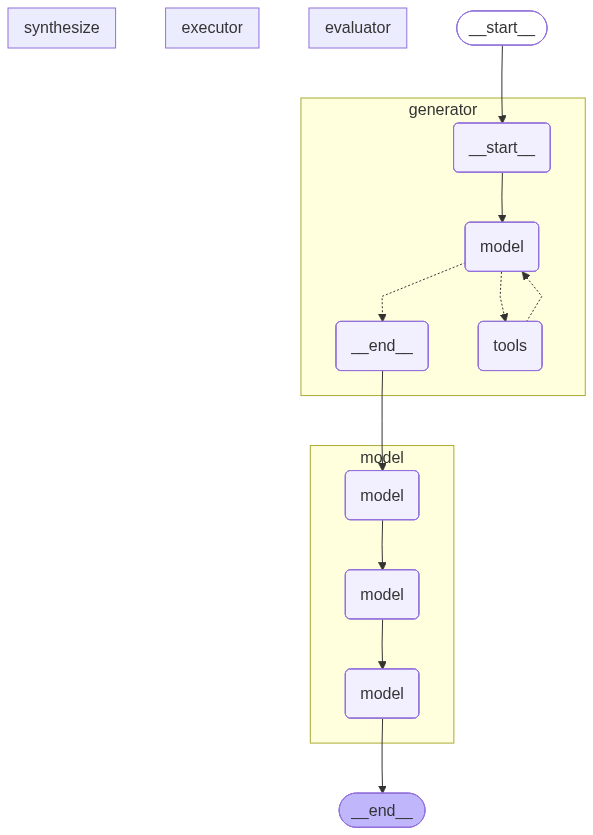

--- Step: generator ---
**Approach 1: Micro‑Influencer Launch Blitz**  
- **Strategy:** Partner with 15‑25 micro‑influencers (5k‑30k followers) across TikTok, Instagram, and YouTube. Offer a flat fee of $250‑$500 plus a commission on sales (10‑15 %). Create short, authentic “sleep‑hack” videos and reels that showcase the mask’s tech features and comfort. Leverage the creator’s existing community by running a limited‑time discount code and a giveaway.  
- **Rationale:**  
  - **High ROI evidence:** The beauty industry averages $5.2 in ROI for every $1 spent on TikTok influencer campaigns (2024 data). Sleep‑related products often see similar or higher engagement because they solve a personal need.  
  - **Credibility & trust:** Micro‑influencers have tighter follower relationships, leading to higher click‑through and conversion rates (often 2–3× higher than macro partners).  
  - **Cost control:** $10 k allows a mix of creator fees and a small reserve for platform boosts.  
  - **Expecte

In [7]:
from IPython.display import display, Image
display("workflow",Image(workflow.get_graph(xray=True).draw_mermaid_png()))   

for r in result.get("results", []):
    print(f"--- Step: {r['source']} ---\n{r['result']}\n")

In [48]:
#prompt chaining: break down complex tasks into smaller, manageable subtasks, instead of using monolithic prompts

"""
When working with complex tasks, model can sometimes drop or miss steps if you try to handle everything in a single prompt. 
Chain of thought (CoT) prompting is great, but what if your task has multiple distinct steps that each require in-depth thought?
Enter prompt chaining: breaking down complex tasks into smaller, manageable subtasks.
Why?
1. Accuracy: Each subtask gets model's full attention, reducing errors.
2. Clarity: Simpler subtasks mean clearer instructions and outputs.
3. Traceability: Easily pinpoint and fix issues in your prompt chain, refining specific prompt for each subtask.
When to use:
- Complex tasks with multiple steps, with a clear sequence
- Tasks needing iterative content creation or refinement
- Multiple transformations, citations, or instructions
"""

# Example: Document Analysis + Email Drafting + Rewrite Document (3 steps)

# without chaining: single prompt
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
import json

llm = init_chat_model(
    model="ollama:gpt-oss:20b",
    temperature=0
)

#source: https://vercel.com/legal/sla
SLA_DOC = """# Enterprise Service Level Agreement

Last Updated July 18, 2024

Service Level Agreement

1. 1. [Services Availability](#services-availability)
   2. [Unscheduled Downtime](#unscheduled-downtime)
   3. [Credits](#credits)

## 1. Services Availability

**Vercel Inc.** ("**Vercel**", "**we**", "**us**" and/or "**our**") will use commercially reasonable efforts to make the platform as a service that serves your content to your websites and/or applications ("**Services**") available 99.99% of the time, excluding any Excused Downtime events, as defined below ("**Services Level**"). The Services availability will be calculated by dividing the total number of minutes in which the Services are up and running and available during an applicable calendar month ("**Uptime**") by the total number of actual minutes in such month minus minutes of Excused Downtime, and then multiplying that amount by 100 ("**Uptime Percentage**"). If the Services fail to meet the above Services Level, you will receive a Credit equal to the result of the Services Credit calculation in [Section 3](#credits) of this SLA.

`Uptime Percentage = Uptime ÷ (Total minutes in month - Excused Downtime) x 100`

Daily system logs will be used to track any Services outages.

## 2. Unscheduled Downtime

Unscheduled Downtime is defined as any time when the Services are not available to perform operations, excluding any outages caused by the failure of any third-party vendor, the Internet in general, factors outside of our reasonable control, outages that resulted from your software or hardware or third party software or hardware, or both or any force majeure event ("**Excused Downtime**"). The measurement is in minutes. For the avoidance of doubt, this SLA does not apply to components of the Vercel platform that do not serve customer content to your websites and/or applications (by way of example only, the API's or CLI).

## 3. Credits

A Credit is the percentage of the monthly Services fees for the Services that is credited to you for an Unscheduled Downtime below the Services Level based on the applicable Uptime Percentage as set forth in the table below. In order to receive any of the Credits described below, you must notify Vercel in writing within thirty (30) days from the time you become eligible to receive a Credit. You must also provide us with log files showing Unscheduled Downtime and the date and time it occurred. If you do not comply with these requirements, you will forfeit your right to receive a Credit. If a dispute arises with respect to this SLA, we will make a determination in good faith based on its system logs, monitoring reports, configuration records, and other available information.

The maximum aggregate number of Credits issued by us to you for all Unscheduled Downtime in a single billing month will not exceed 50% of the amount due from you for the Services for the applicable month. Credits will be in the form of a monetary credit applied to future use of the Services and will be applied within sixty (60) days after the Credit was requested. Credits are your sole and exclusive remedy for any violation of this SLA.

| Monthly Uptime Percentage | Percentage of monthly fee* |
| :--- | :--- |
| 99.1% to 99.98% | 10% |
| 95% to 99% | 25% |
| < 95% | 50% |

* Percentage of monthly fee for the respective Services that does not meet the Service Level that will be credited to your future monthly fees.
"""

SINGLE_PROMPT = """
You are our Chief Legal Officer.

1. Review the following Service Level Agreement (SLA) for risks, focusing on:
- data privacy
- SLA terms
- liability clauses

For each area, identify top 2 risks.
    -> For each risk you identify, provide:
        - Issue: concise description of the finding
        - Risk: potential impact or consequence
        - Mitigation: suggested changes to address the risk

<contract>
{sla_doc}
</contract>

2. Then draft an email to our Account Manager with your concerns and proposed changes to the document.
3. Finally, rewrite the SLA incorporating your proposed changes to address the risks.
"""
single_prompt_messages = [    
    HumanMessage(content=SINGLE_PROMPT.format(sla_doc=SLA_DOC))
]
response = await llm.ainvoke(single_prompt_messages)
single_prompt_messages.append(response)

from IPython.display import display, Markdown
display(Markdown(response.content))


**1. Risk Assessment**

| Area | Top 2 Risks | Issue | Risk | Mitigation |
|------|-------------|-------|------|------------|
| **Data Privacy** | 1. No data‑privacy obligations | The SLA contains no reference to data protection, confidentiality, or compliance with GDPR/CCPA. | Your data may be mishandled, stored in non‑approved jurisdictions, or exposed in a breach without any contractual recourse. | • Add a “Data Privacy & Security” section that: <br>• Requires Vercel to process data only in accordance with applicable privacy laws, <br>• Mandates encryption at rest & in transit, <br>• Specifies data residency, retention, and deletion schedules, <br>• Obligates Vercel to provide breach notification within 72 hrs, and <br>• Requires compliance with SOC 2, ISO 27001, or equivalent. |
| | 2. No breach‑notification or remediation clause | No mechanism to inform us of a data breach or to remediate it. | We could suffer unmitigated loss, regulatory fines, and reputational damage. | • Include a breach‑notification clause (72 hrs), remediation plan, and a right to audit Vercel’s security controls. |
| **SLA Terms** | 1. Over‑broad “Excused Downtime” definition | Excused downtime includes *any* third‑party vendor failure, internet outages, or customer‑hardware/software issues. | Vercel can avoid credits for virtually all outages, undermining the uptime guarantee. | • Narrow the definition to: <br>• Force‑majeure events, <br>• Outages caused by Vercel’s infrastructure or services, <br>• Exclude customer‑controlled hardware/software or third‑party services that are not part of Vercel’s platform. |
| | 2. Credit is the *sole* remedy | The SLA limits us to a credit, with no right to terminate or claim damages. | We may be forced to continue paying for sub‑standard service without any meaningful remedy. | • Add a “Remedies” clause that allows termination for material breach, and/or the right to claim liquidated damages (e.g., 12 months of fees) in addition to credits. |
| **Liability Clauses** | 1. No limitation of liability | Vercel’s liability is unlimited; no cap or exclusion of indirect damages. | We could be exposed to catastrophic losses (e.g., data loss, business interruption). | • Cap Vercel’s liability at 12 months of the fees paid under this SLA, <br>• Exclude indirect, incidental, or consequential damages, <br>• Require indemnification for third‑party claims. |
| | 2. No indemnification or insurance requirement | Vercel does not indemnify us for breaches or failures. | We may bear the cost of legal defense, regulatory fines, or customer claims. | • Insert an indemnification clause where Vercel indemnifies us for claims arising from Vercel’s negligence or breach of the SLA, and require Vercel to maintain adequate cyber‑insurance. |

---

**2. Draft Email to Account Manager**

> **Subject:** Request for Revision of Vercel SLA – Data Privacy, Service Levels & Liability  
>   
> Hi [Account Manager’s Name],  
>   
> I’ve reviewed the current Enterprise SLA and identified several areas that could expose us to significant risk. Below are the key concerns and my suggested changes:  
>   
> 1. **Data Privacy** – The SLA lacks any data‑processing, encryption, or breach‑notification obligations. I propose adding a dedicated “Data Privacy & Security” section that aligns with GDPR/CCPA, requires SOC 2/ISO 27001 compliance, and mandates a 72‑hour breach notification.  
>   
> 2. **Excused Downtime Definition** – The current definition is too broad and effectively removes Vercel’s accountability for most outages. I suggest narrowing it to force‑majeure events and outages caused by Vercel’s own infrastructure.  
>   
> 3. **Remedies** – Credits are the sole remedy. We should have the right to terminate for material breach and claim liquidated damages (12 months of fees).  
>   
> 4. **Liability & Indemnification** – Vercel’s liability is unlimited. I recommend capping liability at 12 months of fees, excluding indirect damages, and adding an indemnification clause backed by cyber‑insurance.  
>   
> Could we schedule a brief call next week to discuss incorporating these changes? I’ve attached a draft of the revised SLA for your review.  
>   
> Thanks for your attention to this matter.  
>   
> Best regards,  
>   
> [Your Name]  
> Chief Legal Officer  
> [Your Company]  

---

**3. Revised SLA (excerpted & updated)**  

> **Enterprise Service Level Agreement**  
> **Last Updated: [Insert Date]**  
>   
> **1. Definitions**  
> - **Services** – All Vercel platform services that deliver customer content to websites/applications.  
> - **Uptime** – Minutes the Services are operational and accessible.  
> - **Excused Downtime** – Outages caused by:  
>   1. Force‑majeure events (as defined in Section 9).  
>   2. Outages of Vercel’s own infrastructure or services.  
>   3. Outages of third‑party services *explicitly integrated* with Vercel (e.g., CDN, DNS) *only if* Vercel is the provider.  
>   4. **Excludes** customer‑controlled hardware/software, third‑party services not integrated with Vercel, and general internet outages.  
>   
> **2. Service Availability**  
> Vercel shall use commercially reasonable efforts to achieve **99.99 %** uptime per calendar month, excluding Excused Downtime.  
> - **Maintenance Windows** – Vercel will provide at least 48 hrs prior notice for planned maintenance that may affect uptime.  
> - **Monitoring & Reporting** – Vercel will publish monthly uptime reports and maintain logs for audit.  
>   
> **3. Credits**  
> - Credits are calculated as per the table below and are the *sole* monetary remedy *unless* Vercel materially breaches the SLA (see Section 7).  
> - Credits are applied within 60 days of a valid claim.  
> - **Maximum Credit** – 50 % of the monthly fee for the affected Services.  
>   
> | Monthly Uptime % | Credit |  
> |-------------------|--------|  
> | 99.1 % – 99.98 % | 10 % |  
> | 95 % – 99 % | 25 % |  
> | < 95 % | 50 % |  
>   
> **4. Data Privacy & Security**  
> - Vercel shall process customer data in compliance with GDPR, CCPA, and any other applicable privacy laws.  
> - Data shall be encrypted at rest and in transit using industry‑standard protocols.  
> - Vercel shall maintain SOC 2 Type II and ISO 27001 certifications (or equivalent) and provide audit reports upon request.  
> - Vercel shall notify the Customer within **72 hours** of any material data breach, provide a remediation plan, and cooperate in any regulatory investigation.  
> - Data residency: Vercel shall store data in the region specified by the Customer unless otherwise agreed.  
> - Data retention: Vercel shall retain data only as long as necessary to provide the Services and shall delete it upon termination of the Agreement.  
>   
> **5. Liability**  
> - Vercel’s total liability under this SLA shall not exceed **12 months of the fees paid** for the Services.  
> - Neither party shall be liable for indirect, incidental, or consequential damages.  
> - Vercel shall maintain cyber‑insurance with limits of at least **$5 million** and shall provide proof upon request.  
>   
> **6. Indemnification**  
> - Each party shall indemnify, defend, and hold harmless the other from any third‑party claim arising from the indemnifying party’s breach of this SLA or negligence.  
>   
> **7. Remedies**  
> - In the event of a material breach of the SLA (e.g., failure to meet uptime guarantee for 3 consecutive months), the Customer may terminate the Agreement with 30 days’ written notice.  
> - The Customer may also claim liquidated damages equal to 12 months of fees, in addition to any credits.  
>   
> **8. Term & Termination**  
> - This Agreement commences on the Effective Date and continues until terminated by either party with 30 days’ notice.  
> - Termination for cause: Either party may terminate immediately if the other materially breaches the SLA and fails to cure within 30 days.  
>   
> **9. Force Majeure**  
> - Neither party shall be liable for failure to perform due to events beyond its reasonable control, including natural disasters, acts of war, or governmental restrictions.  
>   
> **10. Miscellaneous**  
> - This SLA constitutes the entire agreement between the parties regarding its subject matter.  
> - Any amendments must be in writing and signed by both parties.  

*All other sections of the original SLA (e.g., Credits table, Escalation procedures) remain unchanged unless superseded by the above revisions.*

In [49]:
# with chaining: analyze document +  draft email + rewrite document
from langchain_core.messages import HumanMessage, AIMessage
from langchain.chat_models import init_chat_model
from IPython.display import display, Markdown

llm = init_chat_model(
    model="ollama:gpt-oss:20b",
    temperature=0
)
RISK_IDENTIFICATION_PROMPT = """
You are our Chief Legal Officer.
Review the following Service Level Agreement (SLA) for risks, focusing on these areas:
- data privacy
- SLA terms
- liability clauses

For each area, identify top 2 risks.
    -> For each risk you identify, provide:
        - Issue: concise description of the finding
        - Risk: potential impact or consequence
        - Mitigation: suggested changes to address the risk

<contract>
{sla_doc}
</contract>
"""
chained_prompt_messages = [    
    HumanMessage(content=RISK_IDENTIFICATION_PROMPT.format(sla_doc=SLA_DOC))
]
risks = await llm.ainvoke(chained_prompt_messages)
print(risks.content)
chained_prompt_messages.append(AIMessage(content=risks.content))
EMAIL_DRAFTING_PROMPT = """
Draft an email to our Account Manager with your concerns and proposed changes to the document.
"""
chained_prompt_messages.append(HumanMessage(content=EMAIL_DRAFTING_PROMPT))
mail = await llm.ainvoke(chained_prompt_messages)
display(Markdown(mail.content))
chained_prompt_messages.append(AIMessage(content=mail.content))
DRAFT_AMENDMENT_PROMPT = """
Rewrite the original SLA contract to incorporate the proposed changes to mitigate the identified risks.
"""
chained_prompt_messages.append(HumanMessage(content=DRAFT_AMENDMENT_PROMPT))
amended_sla = await llm.ainvoke(chained_prompt_messages)
chained_prompt_messages.append(AIMessage(content=amended_sla.content))
display(Markdown(amended_sla.content))




**High‑Level Risk Assessment – Enterprise Service Level Agreement (SLA)**  
*(Prepared by: Chief Legal Officer – Data Privacy, SLA Terms & Liability Focus)*  

| Focus Area | #1 Risk | #2 Risk |
|------------|---------|---------|
| **Data Privacy** | 1. Absence of a Data Processing / Privacy Addendum | 2. No explicit data‑breach notification or data‑retention policy |
| **SLA Terms** | 1. Broad “Excused Downtime” definition that can exclude many legitimate outages | 2. Credit calculation capped at 50 % of the monthly fee and limited to a single remedy |
| **Liability Clauses** | 1. No limitation or cap on Vercel’s liability | 2. No indemnification or force‑majeure provisions, leaving Vercel exposed to unforeseen events |

Below is a detailed risk‑finding table for each area, including concise issue statements, potential impact, and concrete mitigation recommendations.

---

## 1. Data Privacy

| # | Issue | Risk | Mitigation |
|---|-------|------|------------|
| 1 | **No Data Processin

**Subject:** SLA Review – Key Risk Areas & Suggested Revisions (Vercel Inc.)

Hi [Account Manager’s Name],

I’ve completed a first‑pass review of the Enterprise Service Level Agreement you sent over (Last Updated: July 18 2024). Below are the top risks I identified in the areas of data privacy, SLA terms, and liability, along with concrete changes we’d like to see incorporated before we sign.

---

### 1. Data Privacy

| Issue | Why it matters | Suggested change |
|-------|----------------|------------------|
| **No Data Processing Addendum (DPA)** | Without a DPA, we’re exposed to GDPR/CCPA compliance gaps and unclear data ownership. | Add a separate DPA that: <br>• Identifies Vercel as a processor, us as controller. <br>• Requires appropriate technical & organizational measures (encryption, access controls, audit logs). <br>• Mandates breach notification within 72 hrs (GDPR) / 24 hrs (CCPA). |
| **Missing breach‑notification & retention policy** | Delayed breach response could trigger regulatory fines; indefinite data retention increases risk. | Insert: <br>• “Breach Notification” clause – Vercel must notify us in writing within 72 hrs of a personal‑data breach. <br>• “Data Retention & Deletion” clause – Vercel retains customer data only as long as necessary to provide the Services, then securely deletes or returns it. |

---

### 2. SLA Terms

| Issue | Why it matters | Suggested change |
|-------|----------------|------------------|
| **Broad “Excused Downtime” definition** | Many legitimate outages (e.g., CDN, ISP) would be deemed excused, limiting our recourse. | Narrow the definition to: <br>• Force‑majeure events only (natural disasters, acts of war, etc.). <br>• Explicitly list third‑party services that are “outside of control” and require Vercel to document any outages caused by them. |
| **Credit cap of 50 % & “sole remedy” language** | 50 % credit may not reflect true economic loss; no alternative remedies leaves us under‑compensated. | Replace with: <br>• Tiered liquidated‑damages schedule (10 % for 99.9–99.99 % uptime, 25 % for 99–99.9 %, 50 % for <99 %). <br>• Remove “sole remedy” clause; allow us to pursue additional remedies (damages, injunctions, etc.). |

---

### 3. Liability Clauses

| Issue | Why it matters | Suggested change |
|-------|----------------|------------------|
| **No limitation on Vercel’s liability** | Unlimited exposure to indirect, consequential, or punitive damages. | Add a “Limitation of Liability” clause: Vercel’s liability limited to the total fees paid under this SLA in the preceding 12 months, excluding indirect damages. |
| **No indemnification or force‑majeure provisions** | Unclear responsibilities for third‑party claims; no excuse for extraordinary events. | Insert: <br>• “Indemnification” – Vercel indemnifies us against claims arising from its breach or negligence. <br>• “Force‑Majeure” – Excuses performance and limits liability for events beyond Vercel’s control. |

---

#### Next Steps

1. **Draft the revised clauses** (or provide a template) so we can review the exact language.  
2. **Schedule a brief call** (15–20 min) to walk through the changes and confirm alignment.  
3. **Set a target** to finalize the SLA within the next 10 business days, so we can proceed with onboarding.

Please let me know a convenient time for the call, or feel free to forward the updated draft when ready.

Thanks for your attention to these matters.

Best regards,

[Your Name]  
Chief Legal Officer  
[Your Company]  
[Phone] | [Email]

**Enterprise Service Level Agreement (SLA)**  
*Revised – 18 July 2024 (incorporating risk‑mitigation changes)*  

---

### 0. DEFINITIONS  

| Term | Meaning |
|------|---------|
| **“Services”** | The platform‑as‑a‑service that Vercel Inc. (“Vercel”) provides to host, deliver, and manage the customer’s websites and/or applications. |
| **“Customer”** | The entity that has entered into the Master Agreement with Vercel and is covered by this SLA. |
| **“Uptime”** | The total number of minutes during a calendar month in which the Services are available to the Customer. |
| **“Excused Downtime”** | Outages that are **outside of Vercel’s reasonable control** and are **not** caused by Vercel’s negligence or willful misconduct.  The following events are expressly excluded from the definition of “Unscheduled Downtime” (see § 2):<br>• Force‑majeure events (e.g., natural disasters, acts of war, terrorism, government‑mandated shutdowns).<br>• Outages caused by the Customer’s software, hardware, or third‑party software/hardware that the Customer controls.<br>• Outages caused by the Internet in general, including ISP failures, DNS outages, or routing issues that are not attributable to Vercel.<br>• Outages caused by third‑party services that are **not** part of Vercel’s core infrastructure (e.g., CDN, external APIs, third‑party storage).  Vercel shall provide a **list of such third‑party services** upon request. |
| **“Unscheduled Downtime”** | Any outage that is **not** classified as Excused Downtime and that prevents the Customer from using the Services. |
| **“Service‑Related Outage”** | An Unscheduled Downtime event that is directly attributable to Vercel’s infrastructure, configuration, or operations. |
| **“Service Level”** | The percentage of uptime achieved in a calendar month, calculated as: <br>**Uptime % = (Uptime ÷ (Total minutes in month – Excused Downtime)) × 100** |
| **“Credit”** | A monetary credit applied to the Customer’s future invoices, equal to a percentage of the monthly fee for the Services that were unavailable. |
| **“Data Processing Addendum (DPA)”** | The separate agreement that governs Vercel’s processing of the Customer’s personal data. |
| **“Force‑Majeure”** | Any event beyond the reasonable control of the affected party that prevents or delays performance of the Agreement. |

---

### 1. SERVICES AVAILABILITY  

1.1 **Availability Target** – Vercel will use commercially reasonable efforts to make the Services available **99.99 %** of the time, excluding Excused Downtime.  

1.2 **Measurement** – Uptime will be measured by Vercel’s daily system logs and verified by the Customer upon request.  

1.3 **Reporting** – Vercel shall provide the Customer with a monthly uptime report within 10 business days of the month’s end.  

---

### 2. UNSCHEDULED DOWNTIME  

2.1 **Definition** – Unscheduled Downtime is any period during which the Services are not available to the Customer, **excluding** the events listed in the Excused Downtime definition.  

2.2 **Service‑Related Outage** – Any Unscheduled Downtime that is directly caused by Vercel’s infrastructure, configuration, or operations is a Service‑Related Outage.  

2.3 **Notification** – The Customer shall notify Vercel in writing of any suspected Unscheduled Downtime within 24 hours of discovery.  

---

### 3. CREDITS  

3.1 **Credit Calculation** – Credits are calculated as a percentage of the monthly fee for the Services that were unavailable, based on the Service Level achieved.  

3.2 **Credit Table** – The maximum aggregate Credit for a single billing month is **50 %** of the monthly fee for the affected Services.  

| Monthly Uptime Percentage | Credit (percentage of monthly fee) |
|---------------------------|------------------------------------|
| 99.90 % – 99.99 % | 10 % |
| 99.00 % – 99.89 % | 25 % |
| < 99.00 % | 50 % |

3.3 **Credit Claim** – To claim a Credit, the Customer must:  
&nbsp;&nbsp;a. Provide written notice to Vercel within **30 days** of becoming eligible.  
&nbsp;&nbsp;b. Submit log files and evidence of the Unscheduled Downtime.  

3.4 **Credit Application** – Credits will be applied to the Customer’s future invoices within **60 days** of the Credit request.  

3.5 **Remedies** – Credits are **not** the sole remedy. The Customer may pursue additional remedies, including liquidated damages, specific performance, or termination, as set forth in § 7.  

---

### 4. DATA PROCESSING ADDENDUM (DPA)  

4.1 **Scope** – Vercel shall process the Customer’s personal data only as necessary to provide the Services and in accordance with the DPA.  

4.2 **Security Measures** – Vercel shall implement appropriate technical and organizational measures, including encryption at rest and in transit, access controls, and regular security assessments.  

4.3 **Sub‑processors** – Vercel may engage sub‑processors only after obtaining the Customer’s prior written consent and shall ensure that each sub‑processor is bound by data‑processing obligations no less protective than those in this DPA.  

4.4 **Data Breach Notification** – Vercel shall notify the Customer in writing within **72 hours** of becoming aware of a personal data breach that could affect the Customer’s data.  

4.5 **Data Retention & Deletion** – Vercel shall retain the Customer’s data only for the period necessary to provide the Services, after which it shall securely delete or return the data.  

4.6 **Audit Rights** – The Customer may audit Vercel’s compliance with the DPA upon reasonable notice and during normal business hours.  

---

### 5. DATA BREACH NOTIFICATION (Standalone Clause)  

5.1 **Notification Obligation** – In the event of a personal data breach, Vercel shall notify the Customer in writing within **72 hours** of becoming aware of the breach, providing:  
&nbsp;&nbsp;• A description of the breach, including the type of data involved.  
&nbsp;&nbsp;• The likely impact on the Customer.  
&nbsp;&nbsp;• The remedial actions taken or planned.  

5.2 **Co‑operation** – Vercel shall cooperate with the Customer in any regulatory investigation or notification required by applicable law.  

---

### 6. DATA RETENTION & DELETION (Standalone Clause)  

6.1 **Retention Period** – Vercel shall retain the Customer’s data only for the duration necessary to provide the Services and to comply with legal obligations.  

6.2 **Deletion** – Upon termination of the Agreement or upon the Customer’s written request, Vercel shall delete or return the Customer’s data in a secure manner, except where retention is required by law.  

6.3 **Verification** – Vercel shall provide the Customer with a written confirmation of deletion upon request.  

---

### 7. LIABILITY & INDEMNIFICATION  

7.1 **Limitation of Liability** – Except for liability arising from:  
&nbsp;&nbsp;a. Breach of confidentiality obligations;  
&nbsp;&nbsp;b. Indemnification obligations under § 8;  
&nbsp;&nbsp;c. Willful misconduct or gross negligence;  
&nbsp;&nbsp;d. Breach of the DPA;  
Vercel’s aggregate liability for any claim arising out of or relating to this SLA shall not exceed the **total fees paid by the Customer under this SLA in the preceding 12 months**.  

7.2 **Exclusion of Consequential Damages** – Vercel shall not be liable for indirect, incidental, special, or consequential damages, including loss of revenue, loss of data, or reputational harm.  

7.3 **Indemnification** – Vercel shall indemnify, defend, and hold harmless the Customer from any third‑party claim, demand, or action arising out of:  
&nbsp;&nbsp;a. Vercel’s breach of this SLA or the DPA;  
&nbsp;&nbsp;b. Vercel’s negligence or willful misconduct;  
&nbsp;&nbsp;c. Violation of applicable laws by Vercel.  

7.4 **Notice & Defense** – The indemnified party shall promptly notify the indemnifying party of any claim and shall allow the indemnifying party to control the defense and settlement of the claim, provided that the indemnifying party shall not settle any claim without the indemnified party’s prior written consent.  

---

### 8. FORCE‑MAJEURE  

8.1 **Definition** – A Force‑Majeure event is an event beyond the reasonable control of the affected party that prevents or delays performance of the Agreement.  

8.2 **Effect** – In the event of a Force‑Majeure event, the affected party shall be excused from performance for the duration of the event, and neither party shall be liable for any delay or failure to perform.  

8.3 **Notification** – The affected party shall notify the other party in writing within **5 business days** of the occurrence of a Force‑Majeure event.  

8.4 **Resumption** – Performance shall resume as soon as reasonably possible after the Force‑Majeure event ceases.  

---

### 9. MISCELLANEOUS  

9.1 **Entire Agreement** – This SLA, together with the Master Agreement and the DPA, constitutes the entire agreement between the parties with respect to the Services.  

9.2 **Amendments** – Any amendment to this SLA must be in writing and signed by authorized representatives of both parties.  

9.3 **Severability** – If any provision of this SLA is held invalid or unenforceable, the remaining provisions shall remain in full force and effect.  

9.4 **Governing Law** – This SLA shall be governed by and construed in accordance with the laws of the jurisdiction specified in the Master Agreement.  

9.5 **Dispute Resolution** – Any dispute arising out of or relating to this SLA shall be resolved in accordance with the dispute‑resolution provisions of the Master Agreement.  

---

**Signatures**

| Party | Signature | Name | Title | Date |
|-------|-----------|------|-------|------|
| **Vercel Inc.** | __________________________ | | | |
| **Customer** | __________________________ | | | |

---

In [53]:
#evaluate prompt with LLM-as-a-Judge
llm_judge = init_chat_model(
    model="openai:gpt-5.2",
    #model="ollama:gpt-oss:20b",
    temperature=0, # deterministic for evaluation
    )
evaluation_prompt = """
 You are a judge specialized in evaluating LLM performance on complex tasks.
 Given a conversation between a user and an AI assistant, assess the quality of the assistant's responses.

Your evaluation should consider:
- Accuracy: correctness of the information provided
- Outcome: the format is correct in each subtask requested by the user
- Completeness: extent to which the response addresses the user's query
- Consistency: final response (or subtask) follows intermediate outputs from prior steps

Provide scores from 1 to 10 for each criterion, along with brief justifications and a overall score (out of 10) for the assistant's performance.

Compare the performance between the `single prompt` approach and the `chained prompt` approach of the same task.

Single Prompt Conversation:
{conversation1}

Chained Prompt Conversation:
{conversation2}
"""

evaluate = await llm_judge.ainvoke([
    SystemMessage(content=evaluation_prompt.format(conversation1=single_prompt_messages, conversation2=chained_prompt_messages))])
display(Markdown(evaluate.content.replace("```","\n")))

## Single-prompt approach (one assistant response)

**Accuracy: 6/10**  
- Correctly spots that the SLA is silent on privacy/security and that “Excused Downtime” + “sole remedy” weaken enforceability.  
- However, it mischaracterizes “Liability Clauses” risk: the provided SLA excerpt contains **no liability section at all**, so saying “Vercel’s liability is unlimited” is speculative; the real issue is *absence of liability terms in this SLA* (which likely live in a master agreement).  
- Some proposed edits are commercially unrealistic for an SLA (e.g., “liquidated damages equal to 12 months of fees” on top of credits) and not anchored to the provided document structure.

**Outcome/Format: 7/10**  
- Delivers top-2 risks per area with Issue/Risk/Mitigation, drafts an email, and provides a rewritten SLA.  
- Formatting is mostly usable, though the risk table is a bit muddled (mixes “Top 2 Risks” with Issue/Risk/Mitigation in one row).

**Completeness: 7/10**  
- Addresses all three requested tasks.  
- The rewrite is labeled “excerpted & updated” and does not fully reproduce the original SLA; may be acceptable but the user asked to “rewrite the SLA,” implying a full integrated version.

**Consistency: 6/10**  
- Some internal inconsistencies: it proposes narrowing excused downtime but then the rewrite’s excused downtime definition is confusing (“Outages of Vercel’s own infrastructure” listed as excused is backwards).  
- Liability section recommendations don’t consistently reflect that the original excerpt lacks any liability clause.

**Overall (single prompt): 6.5/10**  
Good issue-spotting on uptime/credits/privacy gaps, but notable legal/structural inaccuracies and some inconsistent drafting in the revised SLA.

---

## Chained-prompt approach (three assistant responses)

**Accuracy: 7/10**  
- Stronger identification of core risks: missing DPA/breach/retention; broad excused downtime; credits as sole remedy.  
- Still has a key conceptual misstep: it treats missing “force majeure” as a liability risk even though force majeure appears indirectly in the definition of Excused Downtime in the original, and again the SLA excerpt has no standalone liability section—so “no limitation/cap” is again speculative (the real finding is “not addressed in this SLA / likely in master terms”).  
- One questionable statement: “24 hrs (CCPA)” breach notice is not a standard CCPA requirement (timing varies; many statutes don’t mandate a fixed 24-hour window).

**Outcome/Format: 9/10**  
- Cleanly follows the requested Issue/Risk/Mitigation structure.  
- Email is well-structured and actionable.  
- Produces a full rewritten SLA-style document with numbered sections.

**Completeness: 9/10**  
- Fully completes all three tasks with more detail than the single prompt.  
- The rewritten SLA integrates privacy/security, remedies, liability, and force majeure clauses.

**Consistency: 7/10**  
- Generally consistent across steps (risks → email → revised SLA).  
- But the rewrite introduces new requirements not previously emphasized or that conflict with earlier suggestions (e.g., “Customer must notify within 24 hours” appears in the rewrite and is not clearly justified; and it keeps a 50% cap while also asserting broader remedies—partially inconsistent with “replace the cap” recommendation).  
- The “Excused Downtime” definition remains very broad and still excludes “Internet in general,” which may undermine the earlier goal of tightening exclusions.

**Overall (chained prompt): 8/10**  
Better structure, clearer execution, and more complete drafting than the single prompt, though it retains some legal inaccuracies and a few inconsistencies between recommendations and incorporated language.

---

## Comparison (single vs chained)

- **Chained > Single** on **format, completeness, and usability** (email + rewrite are more coherent and aligned to the steps).  
- Both approaches share a recurring weakness on **liability analysis**: they infer liability terms from an SLA excerpt that doesn’t contain them, rather than flagging that liability likely sits in a separate master agreement.  
- The chained approach’s revised SLA is more internally coherent overall, despite a few added terms and some mismatch with earlier recommendations.